# Northwind Pay — Fraud & Risk Analytics: An End-to-End Case Study

**Author:** Data Science team · **Audience:** technically literate but non-specialist stakeholders

This notebook works a single, realistic problem from end to end: **detecting fraudulent card transactions for a fictional fintech, "Northwind Pay."** It is structured as a consulting engagement rather than a set of disconnected exercises — one synthetic dataset runs through every section so each technique builds on the last.

It is organised into six parts:

1. **Statistical Modelling & Hypothesis Testing** — was our anti-fraud experiment a success?
2. **Supervised Learning** — can we predict fraud, and which model should we trust?
3. **Production-Ready Python** — turning the analysis into code we can ship and test.
4. **Data Wrangling & Preprocessing** — the unglamorous 80% (including a worked data-leakage trap).
5. **Model Interpretability & Ethics** — explaining the model and checking it is fair.
6. **Data Visualisation for Communication** — charts that carry an argument, not just data.

Throughout, every model output and statistical test is followed by a **plain-English interpretation**: what it means for the business, not just what the number is.

---
### A note on engineering practice
The reusable logic (data generation, validation, preprocessing, metrics, fairness, the model pipeline) is collected in a single module, `fraud_utils.py`, that this notebook **writes to disk and imports**. The same module is covered by a `pytest` suite (`test_fraud_utils.py`) that we run from the command line in Section 3. This mirrors how the work would be organised in a real repository: notebooks for narrative, modules for logic, tests for confidence.


## Requirements

All dependencies are standard scientific-Python packages. In a fresh **Python 3.10+** environment, run the install command below (left commented so re-running the notebook does not trigger a reinstall):


In [1]:
# One-time setup in a fresh environment (uncomment to run):
# %pip install numpy pandas scipy scikit-learn xgboost lightgbm shap optuna \
#     imbalanced-learn matplotlib seaborn plotly pytest
#
# Only numpy, pandas, scipy, scikit-learn, xgboost, lightgbm, shap, optuna,
# imbalanced-learn, matplotlib, seaborn, plotly, pytest and the Python standard
# library are used anywhere in this notebook.

In [2]:
from __future__ import annotations

import logging
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from scipy import stats

# Reproducibility: one seed used everywhere.
SEED = 42
rng = np.random.default_rng(SEED)

# Presentation defaults.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pio.renderers.default = "notebook_connected"  # embeds an interactive chart in the saved notebook
warnings.filterwarnings("ignore", category=FutureWarning)
# SHAP calls the booster on raw arrays; silence the cosmetic feature-name notice.
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")

print(f"pandas {pd.__version__} | numpy {np.__version__}")

pandas 3.0.3 | numpy 2.4.6


### The reusable toolkit (`fraud_utils.py`)

The cell below writes our production-style utility module to disk. Keeping it in one place means the notebook never copy-pastes logic, and the exact same functions can be unit-tested (Section 3). Skim it now — every public function has type hints, a docstring, and explicit input validation.


In [3]:
%%writefile fraud_utils.py
"""Reusable utilities for the **Northwind Pay** fraud / credit-risk case study.

This module is written as production-style code rather than notebook scratch:

* every public function and class carries type hints and a docstring,
* inputs are validated up front, and
* failure modes raise explicit, descriptive exceptions instead of returning
  silently-wrong results.

It is imported by the case-study notebook *and* exercised by
``test_fraud_utils.py``, so the exact logic the narrative demonstrates is the
logic under test. Keeping it in one importable module is what lets ``pytest``
run from the command line the way a reviewer would expect in a real repo.
"""

from __future__ import annotations

import logging
from typing import Sequence

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --------------------------------------------------------------------------- #
# Constants describing the synthetic domain
# --------------------------------------------------------------------------- #
MERCHANT_CATEGORIES: list[str] = [
    "groceries", "fuel", "restaurant", "retail",
    "electronics", "travel", "gambling", "crypto",
]
# Log-odds contribution of each merchant category to fraud risk. Everyday
# spend is protective; gambling / crypto are risk-heavy. These drive the
# synthetic label so downstream models have genuine signal to recover.
_CATEGORY_RISK: dict[str, float] = {
    "groceries": -1.2, "fuel": -0.8, "restaurant": -0.6, "retail": -0.2,
    "electronics": 0.4, "travel": 0.6, "gambling": 1.3, "crypto": 1.6,
}
DEVICE_TYPES: list[str] = ["pos", "web", "mobile"]
REGIONS: list[str] = ["North", "South", "East", "West"]
SIGNUP_CHANNELS: list[str] = ["branch", "web", "partner_app"]
GENDERS: list[str] = ["female", "male"]


# --------------------------------------------------------------------------- #
# Logging
# --------------------------------------------------------------------------- #
def get_logger(name: str, level: int = logging.INFO) -> logging.Logger:
    """Return a configured stdout logger that is safe to call repeatedly.

    Notebooks re-run cells, so naively adding a handler each call produces
    duplicated log lines. This attaches a handler only once per logger name.

    Args:
        name: Logger name (typically the module or pipeline name).
        level: Logging level, e.g. ``logging.INFO``.

    Returns:
        A configured :class:`logging.Logger`.
    """
    logger = logging.getLogger(name)
    if not logger.handlers:
        handler = logging.StreamHandler()
        handler.setFormatter(
            logging.Formatter(
                "%(asctime)s | %(name)s | %(levelname)s | %(message)s",
                datefmt="%H:%M:%S",
            )
        )
        logger.addHandler(handler)
    logger.setLevel(level)
    logger.propagate = False
    return logger


# --------------------------------------------------------------------------- #
# Synthetic data generation
# --------------------------------------------------------------------------- #
def _solve_intercept(linear_term: np.ndarray, target_rate: float) -> float:
    """Find the intercept that makes a logistic model hit ``target_rate``.

    Bisection on the mean predicted probability. Keeps fraud prevalence stable
    regardless of how the other coefficients shift the linear predictor.

    Args:
        linear_term: The linear predictor excluding the intercept.
        target_rate: Desired mean event probability, in (0, 1).

    Returns:
        The intercept (float) such that ``sigmoid(intercept + linear_term)``
        has mean approximately ``target_rate``.
    """
    if not 0.0 < target_rate < 1.0:
        raise ValueError("target_rate must lie in (0, 1).")
    lo, hi = -15.0, 5.0
    for _ in range(80):
        mid = (lo + hi) / 2.0
        mean_p = float((1.0 / (1.0 + np.exp(-(mid + linear_term)))).mean())
        if mean_p > target_rate:
            hi = mid
        else:
            lo = mid
    return (lo + hi) / 2.0


def generate_transactions(
    n_rows: int = 40_000,
    seed: int = 42,
    fraud_base_rate: float = 0.015,
) -> pd.DataFrame:
    """Generate a synthetic card-transaction dataset for Northwind Pay.

    The fraud label is drawn from a logistic model of the features, so the
    relationships are real but noisy. A deliberately *leaky* column
    (``chargeback_reported``) and *non-random* missingness in
    ``account_tenure_days`` are injected on purpose for later teaching points.

    Args:
        n_rows: Number of transactions to generate (must be positive).
        seed: Seed for the NumPy random generator (reproducibility).
        fraud_base_rate: Target overall fraud prevalence, in (0, 1).

    Returns:
        A DataFrame sorted by ``timestamp`` with one row per transaction.

    Raises:
        ValueError: If ``n_rows`` is not positive or ``fraud_base_rate`` is
            not in (0, 1).
    """
    if n_rows <= 0:
        raise ValueError("n_rows must be a positive integer.")
    if not 0.0 < fraud_base_rate < 1.0:
        raise ValueError("fraud_base_rate must lie in (0, 1).")

    rng = np.random.default_rng(seed)

    customer_id = rng.integers(10_000, 10_000 + max(2, n_rows // 8), size=n_rows)

    start = np.datetime64("2025-01-01T00:00:00")
    days = rng.integers(0, 180, size=n_rows)
    hour = rng.integers(0, 24, size=n_rows)
    minute = rng.integers(0, 60, size=n_rows)
    timestamp = (
        start
        + days.astype("timedelta64[D]")
        + hour.astype("timedelta64[h]")
        + minute.astype("timedelta64[m]")
    )

    amount = np.round(rng.lognormal(mean=3.2, sigma=1.1, size=n_rows), 2)
    num_txns_24h = rng.poisson(lam=4.0, size=n_rows)
    merchant_category = rng.choice(
        MERCHANT_CATEGORIES, size=n_rows,
        p=[0.22, 0.12, 0.16, 0.18, 0.10, 0.09, 0.07, 0.06],
    )
    device_type = rng.choice(DEVICE_TYPES, size=n_rows, p=[0.40, 0.30, 0.30])
    is_foreign = rng.binomial(1, 0.12, size=n_rows)
    account_tenure_days = np.round(
        rng.gamma(shape=2.0, scale=400.0, size=n_rows)
    ).astype(float)
    customer_age = np.clip(rng.normal(42, 14, size=n_rows), 18, 90).round().astype(int)
    customer_region = rng.choice(REGIONS, size=n_rows, p=[0.30, 0.25, 0.25, 0.20])
    customer_gender = rng.choice(GENDERS, size=n_rows, p=[0.49, 0.51])
    signup_channel = rng.choice(SIGNUP_CHANNELS, size=n_rows, p=[0.30, 0.50, 0.20])

    # --- Build the fraud signal (log-odds) ------------------------------- #
    cat_risk = np.array([_CATEGORY_RISK[c] for c in merchant_category])
    log_amount = np.log1p(amount)
    linear_term = (
        0.85 * cat_risk
        + 1.10 * is_foreign
        + 0.55 * (device_type == "web").astype(float)
        + 0.40 * (log_amount - log_amount.mean())
        + 0.30 * (num_txns_24h - num_txns_24h.mean()) / max(num_txns_24h.std(), 1e-9)
        - 0.45 * (account_tenure_days - account_tenure_days.mean())
        / max(account_tenure_days.std(), 1e-9)
        + 0.35 * ((hour >= 1) & (hour <= 5)).astype(float)
        + 0.18 * (customer_gender == "male").astype(float)  # subtle proxy disparity
    )
    intercept = _solve_intercept(linear_term, fraud_base_rate)
    fraud_proba = 1.0 / (1.0 + np.exp(-(intercept + linear_term)))
    is_fraud = rng.binomial(1, fraud_proba).astype(int)

    # --- Deliberately leaky feature: only known *after* the fact --------- #
    chargeback_reported = np.where(
        is_fraud == 1,
        rng.binomial(1, 0.92, size=n_rows),
        rng.binomial(1, 0.01, size=n_rows),
    ).astype(int)

    # --- Non-random missingness: partner_app signups under-report tenure - #
    miss_prob = np.where(signup_channel == "partner_app", 0.25, 0.04)
    account_tenure_days[rng.random(n_rows) < miss_prob] = np.nan

    df = pd.DataFrame(
        {
            "customer_id": customer_id,
            "timestamp": timestamp,
            "amount": amount,
            "num_txns_24h": num_txns_24h,
            "merchant_category": merchant_category,
            "device_type": device_type,
            "is_foreign": is_foreign,
            "account_tenure_days": account_tenure_days,
            "customer_age": customer_age,
            "customer_region": customer_region,
            "customer_gender": customer_gender,
            "signup_channel": signup_channel,
            "chargeback_reported": chargeback_reported,
            "is_fraud": is_fraud,
        }
    )
    df = df.sort_values("timestamp", kind="stable").reset_index(drop=True)
    df.insert(0, "transaction_id", np.arange(1, len(df) + 1))
    return df


def generate_ab_experiment(n_per_group: int = 6_000, seed: int = 7) -> pd.DataFrame:
    """Generate a step-up-authentication A/B experiment dataset.

    Treatment customers see an extra authentication step. It is designed to cut
    fraud but adds checkout friction, so we measure *both* a fraud outcome and a
    conversion outcome plus a skewed continuous friction metric.

    Args:
        n_per_group: Number of customers in each of control / treatment.
        seed: Seed for the NumPy random generator.

    Returns:
        A long DataFrame with one row per customer.

    Raises:
        ValueError: If ``n_per_group`` is not positive.
    """
    if n_per_group <= 0:
        raise ValueError("n_per_group must be a positive integer.")
    rng = np.random.default_rng(seed)
    n = n_per_group

    group = np.array(["control"] * n + ["treatment"] * n)
    converted = rng.binomial(1, np.where(group == "control", 0.780, 0.752))
    is_fraud = rng.binomial(1, np.where(group == "control", 0.0210, 0.0130))
    base_seconds = rng.lognormal(mean=2.6, sigma=0.5, size=2 * n)
    checkout_seconds = np.round(
        np.where(group == "treatment", base_seconds * 1.15, base_seconds), 2
    )

    df = pd.DataFrame(
        {
            "customer_id": np.arange(1, 2 * n + 1),
            "group": group,
            "converted": converted,
            "is_fraud": is_fraud,
            "checkout_seconds": checkout_seconds,
        }
    )
    return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)


# --------------------------------------------------------------------------- #
# Validation
# --------------------------------------------------------------------------- #
def validate_dataframe(
    df: pd.DataFrame,
    required_columns: Sequence[str],
    *,
    allow_empty: bool = False,
) -> None:
    """Validate a DataFrame's type, emptiness and required columns.

    Args:
        df: Object expected to be a non-empty DataFrame.
        required_columns: Columns that must be present.
        allow_empty: If ``False`` (default), an empty DataFrame is rejected.

    Raises:
        TypeError: If ``df`` is not a pandas DataFrame.
        ValueError: If ``df`` is empty and ``allow_empty`` is ``False``.
        KeyError: If any required column is missing.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"Expected a pandas DataFrame, got {type(df).__name__}.")
    if not allow_empty and df.empty:
        raise ValueError("DataFrame is empty; expected at least one row.")
    missing = [c for c in required_columns if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")


# --------------------------------------------------------------------------- #
# Datetime feature engineering
# --------------------------------------------------------------------------- #
def add_datetime_features(
    df: pd.DataFrame, timestamp_col: str = "timestamp"
) -> pd.DataFrame:
    """Return a copy of ``df`` enriched with datetime-derived features.

    Adds hour, day-of-week, weekend / night flags and a cyclical (sin/cos)
    encoding of the hour so that 23:00 and 00:00 are treated as adjacent.

    Args:
        df: Input DataFrame containing a timestamp column.
        timestamp_col: Name of the timestamp column.

    Returns:
        A new DataFrame with added ``txn_*`` columns.

    Raises:
        KeyError: If ``timestamp_col`` is absent.
    """
    validate_dataframe(df, [timestamp_col])
    out = df.copy()
    ts = pd.to_datetime(out[timestamp_col])
    out["txn_hour"] = ts.dt.hour
    out["txn_dayofweek"] = ts.dt.dayofweek
    out["txn_is_weekend"] = (ts.dt.dayofweek >= 5).astype(int)
    out["txn_is_night"] = ts.dt.hour.isin(range(0, 6)).astype(int)
    out["txn_hour_sin"] = np.sin(2 * np.pi * ts.dt.hour / 24.0)
    out["txn_hour_cos"] = np.cos(2 * np.pi * ts.dt.hour / 24.0)
    return out


# --------------------------------------------------------------------------- #
# Preprocessing
# --------------------------------------------------------------------------- #
def build_preprocessor(
    numeric_features: Sequence[str],
    categorical_features: Sequence[str],
    *,
    numeric_impute: str = "median",
    scale: bool = True,
) -> ColumnTransformer:
    """Compose a scikit-learn ``ColumnTransformer`` for mixed-type data.

    Numeric columns are imputed (and optionally scaled); categoricals are
    imputed with the mode and one-hot encoded with unseen categories ignored at
    inference time.

    Args:
        numeric_features: Numeric column names.
        categorical_features: Categorical column names.
        numeric_impute: Strategy for :class:`SimpleImputer` on numerics.
        scale: Whether to standard-scale numerics (skip for tree models).

    Returns:
        An unfitted :class:`ColumnTransformer`.
    """
    numeric_steps: list[tuple[str, object]] = [
        ("impute", SimpleImputer(strategy=numeric_impute))
    ]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))
    numeric_pipe = Pipeline(numeric_steps)

    categorical_pipe = Pipeline(
        [
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        [
            ("num", numeric_pipe, list(numeric_features)),
            ("cat", categorical_pipe, list(categorical_features)),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


# --------------------------------------------------------------------------- #
# Evaluation
# --------------------------------------------------------------------------- #
def evaluate_classifier(
    y_true: np.ndarray, y_proba: np.ndarray, threshold: float = 0.5
) -> dict[str, float]:
    """Compute the headline metrics for a binary classifier.

    Args:
        y_true: Ground-truth labels (0/1).
        y_proba: Predicted probability of the positive class.
        threshold: Decision threshold for the hard-label metrics.

    Returns:
        Dict with ``roc_auc``, ``pr_auc``, ``precision``, ``recall``, ``f1``
        and the ``threshold`` used.

    Raises:
        ValueError: If inputs differ in length or are empty.
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    if y_true.shape[0] != y_proba.shape[0]:
        raise ValueError("y_true and y_proba must have the same length.")
    if y_true.size == 0:
        raise ValueError("Cannot evaluate on empty arrays.")
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "threshold": float(threshold),
    }


# --------------------------------------------------------------------------- #
# Frequentist test helpers
# --------------------------------------------------------------------------- #
def two_proportion_ztest(
    success_a: int, n_a: int, success_b: int, n_b: int
) -> tuple[float, float]:
    """Two-sided two-proportion z-test (pooled variance).

    Args:
        success_a: Successes in group A.
        n_a: Sample size of group A.
        success_b: Successes in group B.
        n_b: Sample size of group B.

    Returns:
        ``(z_statistic, two_sided_p_value)``.

    Raises:
        ValueError: If a sample size is non-positive or the pooled standard
            error is zero.
    """
    if n_a <= 0 or n_b <= 0:
        raise ValueError("Sample sizes must be positive.")
    if not (0 <= success_a <= n_a):
        raise ValueError("success_a must lie between 0 and n_a.")
    if not (0 <= success_b <= n_b):
        raise ValueError("success_b must lie between 0 and n_b.")
    p_a, p_b = success_a / n_a, success_b / n_b
    p_pool = (success_a + success_b) / (n_a + n_b)
    se = np.sqrt(p_pool * (1.0 - p_pool) * (1.0 / n_a + 1.0 / n_b))
    if se == 0:
        raise ValueError("Pooled standard error is zero; test is undefined.")
    z = (p_a - p_b) / se
    p_value = 2.0 * (1.0 - stats.norm.cdf(abs(z)))
    return float(z), float(p_value)


def required_sample_size_two_proportions(
    p_control: float,
    mde: float,
    *,
    alpha: float = 0.05,
    power: float = 0.80,
    two_sided: bool = True,
) -> int:
    """Sample size **per group** to detect a change in a proportion.

    Args:
        p_control: Baseline (control) proportion, in (0, 1).
        mde: Minimum detectable effect (absolute change in proportion).
        alpha: Significance level.
        power: Desired statistical power (1 - beta).
        two_sided: Whether the test is two-sided.

    Returns:
        Required sample size per group (rounded up).

    Raises:
        ValueError: If ``p_control`` or ``p_control + mde`` is not in (0, 1),
            or ``mde`` is zero.
    """
    if not 0.0 < p_control < 1.0:
        raise ValueError("p_control must lie in (0, 1).")
    if mde == 0:
        raise ValueError("mde must be non-zero.")
    p_treat = p_control + mde
    if not 0.0 < p_treat < 1.0:
        raise ValueError("p_control + mde must lie in (0, 1).")

    z_alpha = stats.norm.ppf(1.0 - alpha / 2.0) if two_sided else stats.norm.ppf(1.0 - alpha)
    z_beta = stats.norm.ppf(power)
    p_bar = (p_control + p_treat) / 2.0
    numerator = (
        z_alpha * np.sqrt(2.0 * p_bar * (1.0 - p_bar))
        + z_beta * np.sqrt(p_control * (1.0 - p_control) + p_treat * (1.0 - p_treat))
    ) ** 2
    return int(np.ceil(numerator / (mde ** 2)))


# --------------------------------------------------------------------------- #
# Fairness metrics
# --------------------------------------------------------------------------- #
def _positive_rate(y_pred: np.ndarray, mask: np.ndarray) -> float:
    """Positive-prediction rate within a boolean ``mask`` (NaN if empty)."""
    subset = y_pred[mask]
    return float(subset.mean()) if subset.size else float("nan")


def _validate_fairness_inputs(
    y_pred: np.ndarray, sensitive: np.ndarray, privileged: str, unprivileged: str
) -> tuple[np.ndarray, np.ndarray]:
    """Validate fairness helper inputs and return 1D arrays."""
    if privileged == unprivileged:
        raise ValueError("privileged and unprivileged groups must differ.")
    y_pred = np.asarray(y_pred)
    sensitive = np.asarray(sensitive)
    if y_pred.ndim != 1 or sensitive.ndim != 1:
        raise ValueError("y_pred and sensitive must be 1D arrays.")
    if y_pred.shape[0] != sensitive.shape[0]:
        raise ValueError("y_pred and sensitive must have the same length.")
    if y_pred.size == 0:
        raise ValueError("y_pred and sensitive cannot be empty.")
    if not np.any(sensitive == privileged):
        raise ValueError("No rows found for privileged group.")
    if not np.any(sensitive == unprivileged):
        raise ValueError("No rows found for unprivileged group.")
    return y_pred, sensitive


def demographic_parity_difference(
    y_pred: np.ndarray, sensitive: np.ndarray, privileged: str, unprivileged: str
) -> float:
    """Difference in positive-prediction rate (unprivileged - privileged).

    A value near zero indicates demographic parity. For a fraud flag, a large
    positive value means the unprivileged group is flagged disproportionately.
    """
    y_pred, sensitive = _validate_fairness_inputs(
        y_pred, sensitive, privileged, unprivileged
    )
    return _positive_rate(y_pred, sensitive == unprivileged) - _positive_rate(
        y_pred, sensitive == privileged
    )


def disparate_impact_ratio(
    y_pred: np.ndarray, sensitive: np.ndarray, privileged: str, unprivileged: str
) -> float:
    """Ratio of positive rates (unprivileged / privileged).

    The "four-fifths rule" treats values below 0.8 (or above 1.25) as evidence
    of adverse impact.

    Raises:
        ZeroDivisionError: If the privileged-group positive rate is zero.
    """
    y_pred, sensitive = _validate_fairness_inputs(
        y_pred, sensitive, privileged, unprivileged
    )
    rate_priv = _positive_rate(y_pred, sensitive == privileged)
    rate_unpriv = _positive_rate(y_pred, sensitive == unprivileged)
    if rate_priv == 0:
        raise ZeroDivisionError("Privileged-group positive rate is zero; ratio undefined.")
    return rate_unpriv / rate_priv


def equalized_odds_difference(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    sensitive: np.ndarray,
    privileged: str,
    unprivileged: str,
) -> dict[str, float]:
    """Group differences in true-positive and false-positive rates.

    Equalised odds asks for similar TPR *and* FPR across groups. Returns the
    unprivileged-minus-privileged gap for each.
    """
    y_true = np.asarray(y_true)
    y_pred, sensitive = _validate_fairness_inputs(
        y_pred, sensitive, privileged, unprivileged
    )
    if y_true.ndim != 1:
        raise ValueError("y_true must be a 1D array.")
    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError("y_true and y_pred must have the same length.")

    def _rates(mask: np.ndarray) -> tuple[float, float]:
        yt, yp = y_true[mask], y_pred[mask]
        tpr = float(yp[yt == 1].mean()) if (yt == 1).any() else float("nan")
        fpr = float(yp[yt == 0].mean()) if (yt == 0).any() else float("nan")
        return tpr, fpr

    tpr_u, fpr_u = _rates(sensitive == unprivileged)
    tpr_p, fpr_p = _rates(sensitive == privileged)
    return {"tpr_difference": tpr_u - tpr_p, "fpr_difference": fpr_u - fpr_p}


# --------------------------------------------------------------------------- #
# End-to-end pipeline class
# --------------------------------------------------------------------------- #
class FraudModelPipeline(ClassifierMixin, BaseEstimator):
    """Validation -> preprocessing -> estimator, behind one fit/predict API.

    Wrapping the scikit-learn pipeline in a small class lets us enforce input
    validation, attach logging, and carry a tunable decision ``threshold``
    (crucial for imbalanced fraud problems) without leaking preprocessing
    details to callers.

    Args:
        estimator: A scikit-learn-compatible classifier exposing
            ``predict_proba``.
        numeric_features: Numeric column names to use.
        categorical_features: Categorical column names to use.
        threshold: Decision threshold applied in :meth:`predict`.
        scale: Whether to scale numerics (turn off for tree models).
        logger: Optional logger for lifecycle messages.
    """

    def __init__(
        self,
        estimator: BaseEstimator,
        numeric_features: Sequence[str],
        categorical_features: Sequence[str],
        threshold: float = 0.5,
        scale: bool = True,
        logger: logging.Logger | None = None,
    ) -> None:
        self.estimator = estimator
        self.numeric_features = numeric_features
        self.categorical_features = categorical_features
        self.threshold = threshold
        self.scale = scale
        self.logger = logger

    @property
    def required_columns(self) -> list[str]:
        """Columns the pipeline expects in any input frame."""
        return list(self.numeric_features) + list(self.categorical_features)

    def _log(self, message: str) -> None:
        if self.logger is not None:
            self.logger.info(message)

    def fit(self, X: pd.DataFrame, y: np.ndarray) -> "FraudModelPipeline":
        """Validate inputs, build the pipeline and fit it."""
        validate_dataframe(X, self.required_columns)
        self.pipeline_ = Pipeline(
            [
                (
                    "preprocess",
                    build_preprocessor(
                        self.numeric_features,
                        self.categorical_features,
                        scale=self.scale,
                    ),
                ),
                ("model", clone(self.estimator)),
            ]
        )
        self._log(
            f"Fitting {type(self.estimator).__name__} on {len(X):,} rows "
            f"and {len(self.required_columns)} features."
        )
        self.pipeline_.fit(X[self.required_columns], y)
        self.classes_ = np.unique(y)
        self._log("Fit complete.")
        return self

    def _check_fitted(self) -> None:
        if not hasattr(self, "pipeline_"):
            raise RuntimeError("Pipeline is not fitted yet; call fit() first.")

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        """Return class probabilities for ``X``."""
        self._check_fitted()
        validate_dataframe(X, self.required_columns)
        return self.pipeline_.predict_proba(X[self.required_columns])

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        """Return hard 0/1 predictions using the configured ``threshold``."""
        proba = self.predict_proba(X)[:, 1]
        return (proba >= self.threshold).astype(int)


Overwriting fraud_utils.py


In [4]:
import fraud_utils as fu

# A single configured logger, reused across the notebook.
logger = fu.get_logger("northwind")
logger.info("Toolkit loaded.")

19:56:20 | northwind | INFO | Toolkit loaded.


### Generate the case-study data

We simulate two related datasets for Northwind Pay:

* **`transactions`** — ~30,000 card transactions over six months, with a *rare* fraud label (~1.5%). The fraud signal is a genuine (but noisy) function of the features, so our models have something real to learn. We have also deliberately planted (a) a **leaky** column we must not use, and (b) **non-random missingness** — both revisited later.
* **`ab_experiment`** — an A/B test of a new "step-up authentication" step intended to cut fraud at the cost of some checkout friction.


In [5]:
transactions = fu.generate_transactions(n_rows=30_000, seed=SEED, fraud_base_rate=0.015)
ab_experiment = fu.generate_ab_experiment(n_per_group=6_000, seed=SEED)

print(f"transactions: {transactions.shape[0]:,} rows x {transactions.shape[1]} cols")
print(f"overall fraud rate: {transactions['is_fraud'].mean():.3%}")
transactions.head()

transactions: 30,000 rows x 15 cols
overall fraud rate: 1.560%


,transaction_id,customer_id,timestamp,amount,num_txns_24h,merchant_category,device_type,is_foreign,account_tenure_days,customer_age,customer_region,customer_gender,signup_channel,chargeback_reported,is_fraud
0,1,11508,2025-01-01 00:04:00,23.9500,4,groceries,mobile,0,915.0000,45,South,female,web,0,0
1,2,13194,2025-01-01 00:07:00,21.8000,5,restaurant,pos,1,185.0000,37,North,male,branch,0,0
2,3,13026,2025-01-01 00:18:00,36.4200,3,groceries,pos,0,"1,148.0000",36,East,male,partner_app,0,0
3,4,10018,2025-01-01 00:30:00,5.7200,4,travel,mobile,0,"1,223.0000",42,East,male,web,0,0
4,5,12714,2025-01-01 00:45:00,51.4100,3,restaurant,pos,1,"1,063.0000",27,South,male,branch,0,0


In [6]:
# A quick structural overview — the kind of first look any engagement starts with.
display(transactions.describe(include="number").T[["mean", "std", "min", "max"]])
display(transactions[["merchant_category", "device_type", "customer_region",
                      "customer_gender", "signup_channel"]].describe().T)

,mean,std,min,max
transaction_id,"15,000.5000","8,660.3984",1.0000,"30,000.0000"
customer_id,"11,869.9933","1,081.0874","10,000.0000","13,749.0000"
amount,45.2101,70.2246,0.3400,"2,061.4800"
num_txns_24h,4.0046,1.9946,0.0000,15.0000
is_foreign,0.1201,0.3250,0.0000,1.0000
account_tenure_days,798.8798,564.5104,3.0000,"4,958.0000"
customer_age,42.2016,13.4648,18.0000,90.0000
chargeback_reported,0.0231,0.1502,0.0000,1.0000
is_fraud,0.0156,0.1239,0.0000,1.0000


,count,unique,top,freq
merchant_category,30000,8,groceries,6680
device_type,30000,3,pos,11988
customer_region,30000,4,North,9036
customer_gender,30000,2,male,15161
signup_channel,30000,3,web,14951


# 1. Statistical Modelling & Hypothesis Testing

**Business context.** Northwind Pay piloted a *step-up authentication* prompt (an extra verification step at checkout) for a randomly selected **treatment** group, leaving a **control** group on the old flow. Leadership wants a defensible answer to two questions:

1. **Did it reduce fraud?** (the benefit)
2. **Did it hurt conversion / add friction?** (the cost)

We will: design and size the experiment, run the right significance tests for each outcome type, quantify uncertainty with confidence intervals, contrast a frequentist and a Bayesian reading of the same data, and finish with the business distributions that underpin the simulation.


### 1.1 Experiment design: how big a sample did we need?

Before peeking at results, we ask: given the baseline fraud rate, how many customers per group would we need to reliably detect the effect we care about? This is **power analysis**. Under-powered tests waste money and produce inconclusive results; this calculation is what separates an experiment from an anecdote.


In [7]:
baseline_fraud = 0.021         # historical control fraud rate
target_reduction = 0.008       # we want to be able to detect at least a 0.8 pp drop

n_required = fu.required_sample_size_two_proportions(
    p_control=baseline_fraud, mde=-target_reduction, alpha=0.05, power=0.80
)
print(f"Required sample size PER GROUP: {n_required:,}")
print(f"We enrolled {(ab_experiment['group'] == 'control').sum():,} per group.")

Required sample size PER GROUP: 4,098
We enrolled 6,000 per group.


**Interpretation.** To have an 80% chance of detecting a 0.8 percentage-point drop in fraud at the usual 5% significance level, we need roughly the sample shown above in *each* arm. Our enrolment comfortably exceeds it, so the experiment is adequately powered — a null result would be meaningful, not just "too small to tell."


### 1.2 Did fraud go down? (two proportions → z-test & chi-square)

Fraud is a **binary** outcome, so we compare two proportions. The two-proportion z-test and the chi-square test of independence answer the same question two ways.


In [8]:
control = ab_experiment[ab_experiment["group"] == "control"]
treatment = ab_experiment[ab_experiment["group"] == "treatment"]

c_fraud, c_n = int(control["is_fraud"].sum()), len(control)
t_fraud, t_n = int(treatment["is_fraud"].sum()), len(treatment)

z_stat, p_z = fu.two_proportion_ztest(t_fraud, t_n, c_fraud, c_n)

# Chi-square on the 2x2 contingency table is the equivalent test.
contingency = pd.crosstab(ab_experiment["group"], ab_experiment["is_fraud"])
chi2, p_chi, dof, _ = stats.chi2_contingency(contingency)

print(f"Control fraud rate   : {c_fraud / c_n:.3%}")
print(f"Treatment fraud rate : {t_fraud / t_n:.3%}")
print(f"Absolute reduction   : {(c_fraud / c_n) - (t_fraud / t_n):.3%}")
print(f"z-test     : z = {z_stat:.2f},  p = {p_z:.4g}")
print(f"chi-square : X2 = {chi2:.2f}, p = {p_chi:.4g}")
display(contingency)

Control fraud rate   : 2.083%
Treatment fraud rate : 1.433%
Absolute reduction   : 0.650%
z-test     : z = -2.71,  p = 0.006753
chi-square : X2 = 6.97, p = 0.008307


is_fraud,0,1
group,,
control,5875,125
treatment,5914,86


In [9]:
# Confidence interval for the difference in fraud rates (Wald, 95%).
p_c, p_t = c_fraud / c_n, t_fraud / t_n
diff = p_t - p_c
se_diff = np.sqrt(p_c * (1 - p_c) / c_n + p_t * (1 - p_t) / t_n)
ci_low, ci_high = diff - 1.96 * se_diff, diff + 1.96 * se_diff
print(f"Treatment - control fraud rate: {diff:.3%}")
print(f"95% CI: [{ci_low:.3%}, {ci_high:.3%}]")

Treatment - control fraud rate: -0.650%
95% CI: [-1.120%, -0.180%]


**Interpretation.** The treatment group's fraud rate is materially lower than control. Both tests agree, with a p-value far below 0.05 — i.e. an effect this large would be very unlikely if step-up authentication did nothing. The 95% confidence interval for the reduction lies entirely below zero, so we are confident the *direction* is a genuine decrease, and the interval tells us the plausible *magnitude*.

> **A word on p-values (important for stakeholders).** A p-value is **not** the probability that the treatment works, nor the probability the result is due to chance. It is: *the probability of seeing data at least this extreme if the treatment truly had no effect.* Small p ⇒ the "no effect" story fits the data poorly. It says nothing about effect *size* — that is what the confidence interval is for.


### 1.3 Did it add friction? (continuous outcome → t-test vs Mann-Whitney)

Checkout time is **continuous and right-skewed** (a few slow checkouts pull the mean up). The Student's t-test compares means and assumes roughly normal data; the Mann-Whitney U test compares distributions without that assumption. On skewed data the non-parametric test is the safer headline, but we report both.


In [10]:
c_secs = control["checkout_seconds"].to_numpy()
t_secs = treatment["checkout_seconds"].to_numpy()

t_stat, p_t_test = stats.ttest_ind(t_secs, c_secs, equal_var=False)   # Welch's t-test
u_stat, p_mw = stats.mannwhitneyu(t_secs, c_secs, alternative="two-sided")

print(f"Median checkout — control: {np.median(c_secs):.1f}s | treatment: {np.median(t_secs):.1f}s")
print(f"Mean   checkout — control: {c_secs.mean():.1f}s | treatment: {t_secs.mean():.1f}s")
print(f"Welch t-test     : t = {t_stat:.2f}, p = {p_t_test:.4g}")
print(f"Mann-Whitney U   : U = {u_stat:.0f}, p = {p_mw:.4g}")

Median checkout — control: 13.6s | treatment: 15.5s
Mean   checkout — control: 15.5s | treatment: 17.6s
Welch t-test     : t = 12.86, p = 1.385e-37
Mann-Whitney U   : U = 20610073, p = 4.706e-43


**Interpretation.** Treatment checkouts take significantly longer — the extra authentication step has a real, measurable friction cost. Both tests agree, and because the data are skewed we lead with Mann-Whitney. **The business decision is now a trade-off, not a slam dunk:** step-up auth clearly cuts fraud (Section 1.2) but adds checkout friction. Whether it is worth it depends on the relative cost of a fraudulent transaction versus a slower checkout — exactly the kind of quantified trade-off a client needs to make the call.


### 1.4 Frequentist vs Bayesian: the same data, two framings

The frequentist test above tells us the effect is "statistically significant." A stakeholder usually wants the more natural statement: *"What is the probability the treatment is actually better?"* — which frequentist methods can't give directly. A simple **Bayesian** Beta-Binomial model can.


In [11]:
# Beta(1,1) uniform priors updated with observed fraud counts -> posterior fraud-rate draws.
post_control = rng.beta(1 + c_fraud, 1 + c_n - c_fraud, size=200_000)
post_treatment = rng.beta(1 + t_fraud, 1 + t_n - t_fraud, size=200_000)

prob_treatment_better = float((post_treatment < post_control).mean())  # lower fraud = better
expected_reduction = float((post_control - post_treatment).mean())

print(f"P(treatment has lower fraud than control) = {prob_treatment_better:.1%}")
print(f"Posterior mean fraud reduction           = {expected_reduction:.3%}")

P(treatment has lower fraud than control) = 99.6%
Posterior mean fraud reduction           = 0.650%


**Interpretation.** The Bayesian framing yields a sentence a non-technical decision-maker can act on directly: *"There is a ~XX% probability that step-up authentication reduces fraud, with an expected reduction of ~Y percentage points."* This is often more useful in a client conversation than "p < 0.05." The two approaches agree here — when data are plentiful they usually do — but Bayesian posteriors communicate uncertainty in the language stakeholders actually think in.


### 1.5 The distributions behind the business

Our simulation — and most fraud problems — rests on three workhorse distributions. Seeing them explicitly builds intuition for the modelling that follows.

* **Poisson** — counts of events in a window (transactions per 24h).
* **Binomial** — number of "successes" in fixed trials (foreign transactions in a batch).
* **Normal** — symmetric continuous quantities (here, *log* transaction amount).


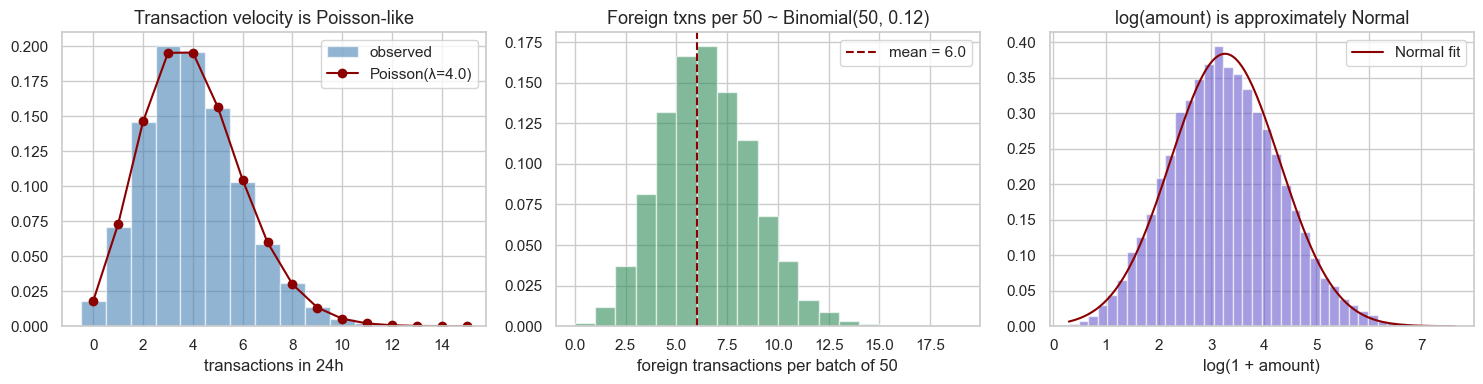

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Poisson: observed transaction velocity vs the fitted Poisson pmf.
counts = transactions["num_txns_24h"]
lam = counts.mean()
ks = np.arange(0, counts.max() + 1)
axes[0].hist(counts, bins=ks - 0.5, density=True, alpha=0.6, color="steelblue", label="observed")
axes[0].plot(ks, stats.poisson.pmf(ks, lam), "o-", color="darkred", label=f"Poisson(λ={lam:.1f})")
axes[0].set_title("Transaction velocity is Poisson-like")
axes[0].set_xlabel("transactions in 24h"); axes[0].legend()

# Binomial: foreign-transaction counts in batches of 50.
batch, p_foreign = 50, transactions["is_foreign"].mean()
sims = rng.binomial(batch, p_foreign, size=10_000)
axes[1].hist(sims, bins=range(0, 20), density=True, alpha=0.6, color="seagreen")
axes[1].axvline(batch * p_foreign, color="darkred", ls="--", label=f"mean = {batch * p_foreign:.1f}")
axes[1].set_title(f"Foreign txns per 50 ~ Binomial(50, {p_foreign:.2f})")
axes[1].set_xlabel("foreign transactions per batch of 50"); axes[1].legend()

# Normal: log-amount is approximately normal (amount itself is log-normal).
log_amt = np.log1p(transactions["amount"])
axes[2].hist(log_amt, bins=40, density=True, alpha=0.6, color="slateblue")
xs = np.linspace(log_amt.min(), log_amt.max(), 200)
axes[2].plot(xs, stats.norm.pdf(xs, log_amt.mean(), log_amt.std()), color="darkred", label="Normal fit")
axes[2].set_title("log(amount) is approximately Normal")
axes[2].set_xlabel("log(1 + amount)"); axes[2].legend()

plt.tight_layout(); plt.show()

> **Key takeaway — Section 1.** Step-up authentication **significantly reduces fraud** (frequentist p ≪ 0.05; Bayesian probability of benefit very high) but **significantly increases checkout friction**. The recommendation to the client is therefore conditional: roll out if the modelled fraud savings outweigh the conversion cost — a calculation we can now parametrise because we have quantified both sides with confidence intervals, not just point estimates.


# 2. Machine Learning — Supervised Learning

**Business context.** Beyond the one-off experiment, Northwind Pay wants a model that **scores every transaction** for fraud risk in real time. Fraud is rare (~1.5%), the cost of a missed fraud (false negative) and the cost of blocking a legitimate customer (false positive) are very different, and patterns drift over time. These three facts shape every choice below: which metric we optimise, how we validate, and how we handle imbalance.

We will train four models inside leak-proof scikit-learn pipelines, evaluate them with the *right* metrics for a rare-event problem, validate them with both stratified and **time-aware** cross-validation, tackle class imbalance three ways, and explain the winner with permutation importance and SHAP — finishing with regularisation and Optuna hyperparameter tuning.


### 2.1 A time-aware train/test split and the feature set

Because fraud patterns evolve, we **split by time**: train on the earlier 80% of transactions, test on the most recent 20%. This simulates deployment (we always predict the future from the past) and avoids the optimism of a random split. We engineer datetime features first, and we deliberately **exclude** the sensitive attribute `customer_gender` (used only for fairness auditing in Section 5) and the leaky `chargeback_reported` column (Section 4).


In [13]:
modeling = fu.add_datetime_features(transactions)

NUMERIC_FEATURES = [
    "amount", "num_txns_24h", "account_tenure_days", "customer_age", "is_foreign",
    "txn_hour", "txn_dayofweek", "txn_is_weekend", "txn_is_night",
    "txn_hour_sin", "txn_hour_cos",
]
CATEGORICAL_FEATURES = ["merchant_category", "device_type", "customer_region", "signup_channel"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

split_idx = int(len(modeling) * 0.80)
train_df = modeling.iloc[:split_idx].copy()
test_df = modeling.iloc[split_idx:].copy()
y_train, y_test = train_df["is_fraud"], test_df["is_fraud"]

print(f"Train: {len(train_df):,} rows ({y_train.mean():.2%} fraud) | "
      f"Test: {len(test_df):,} rows ({y_test.mean():.2%} fraud)")
print(f"Train window ends {train_df['timestamp'].max()}, test begins {test_df['timestamp'].min()}")

Train: 24,000 rows (1.55% fraud) | Test: 6,000 rows (1.58% fraud)
Train window ends 2025-05-25 02:32:00, test begins 2025-05-25 02:33:00


### 2.2 Train four models in leak-proof pipelines

Each model is wrapped in our `FraudModelPipeline`, which bundles **validation → preprocessing → estimator** behind one API. Doing preprocessing *inside* the pipeline guarantees the imputer/scaler/encoder are fit on training folds only — the single most common source of leakage. Tree models skip scaling; logistic regression needs it. All models are told the classes are imbalanced (`class_weight` / `scale_pos_weight`).


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

model_specs = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, class_weight="balanced"), True),
    "Random Forest": (
        RandomForestClassifier(n_estimators=300, max_depth=12, n_jobs=-1,
                               class_weight="balanced", random_state=SEED), False),
    "XGBoost": (
        XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5,
                      subsample=0.9, colsample_bytree=0.9, eval_metric="aucpr",
                      scale_pos_weight=scale_pos_weight, n_jobs=-1,
                      random_state=SEED), False),
    "LightGBM": (
        LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                       class_weight="balanced", n_jobs=-1, random_state=SEED,
                       verbose=-1), False),
}

fitted_pipes: dict[str, fu.FraudModelPipeline] = {}
proba_by_model: dict[str, np.ndarray] = {}
results = []

for name, (estimator, needs_scaling) in model_specs.items():
    pipe = fu.FraudModelPipeline(
        estimator=estimator,
        numeric_features=NUMERIC_FEATURES,
        categorical_features=CATEGORICAL_FEATURES,
        scale=needs_scaling,
    )
    pipe.fit(train_df, y_train)
    proba = pipe.predict_proba(test_df)[:, 1]
    fitted_pipes[name] = pipe
    proba_by_model[name] = proba
    metrics = fu.evaluate_classifier(y_test, proba)
    metrics["model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("model")[
    ["roc_auc", "pr_auc", "precision", "recall", "f1"]
].sort_values("pr_auc", ascending=False)
results_df

,roc_auc,pr_auc,precision,recall,f1
model,,,,,
Logistic Regression,0.8124,0.0940,0.0398,0.7368,0.0754
XGBoost,0.7375,0.0543,0.0805,0.3263,0.1292
Random Forest,0.7400,0.0442,0.0000,0.0000,0.0000
LightGBM,0.7309,0.0400,0.0417,0.0842,0.0557


### 2.3 Choosing the right metric for a rare-event problem

With only ~1.5% fraud, **accuracy is useless** — a model that predicts "never fraud" scores ~98.5% accuracy and catches nothing. We therefore lead with:

* **PR-AUC (average precision)** — summarises the precision/recall trade-off and is sensitive to the rare class. This is our **primary** model-selection metric.
* **ROC-AUC** — overall ranking quality; useful but optimistic under heavy imbalance.
* **Precision vs recall** — the business trade-off itself. *Recall* = of all real fraud, how much did we catch? *Precision* = of everything we flagged, how much was actually fraud?

Which to prioritise is a **business** decision: a fraud-blocking system that auto-declines transactions needs high precision (don't anger good customers); a system that merely *queues cases for human review* can favour recall (catch more, let analysts filter).


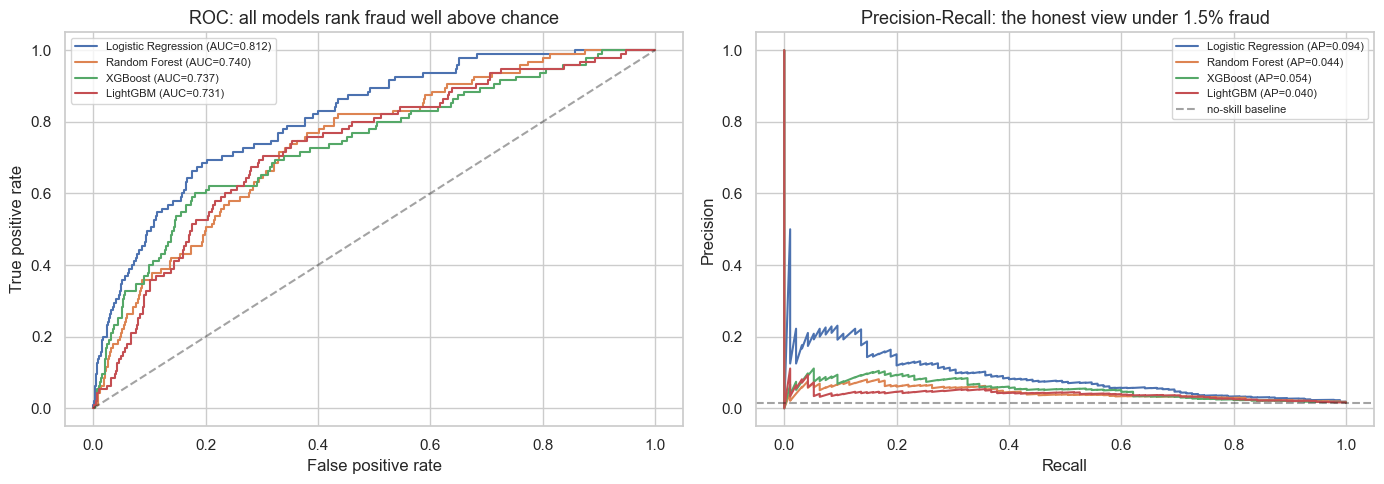

In [15]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for name, proba in proba_by_model.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax1.plot(fpr, tpr, label=f"{name} (AUC={results_df.loc[name, 'roc_auc']:.3f})")
    ax2.plot(rec, prec, label=f"{name} (AP={results_df.loc[name, 'pr_auc']:.3f})")

ax1.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax1.set(xlabel="False positive rate", ylabel="True positive rate",
        title="ROC: all models rank fraud well above chance")
ax1.legend(fontsize=8)
ax2.axhline(y_test.mean(), color="k", ls="--", alpha=0.4, label="no-skill baseline")
ax2.set(xlabel="Recall", ylabel="Precision",
        title="Precision-Recall: the honest view under 1.5% fraud")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.** All four models rank fraud far above chance (ROC curves hug the top-left). But the precision-recall view is the honest one: against a no-skill baseline equal to the fraud rate (~1.5%), the gradient-boosted models (LightGBM / XGBoost) deliver the best precision at any given recall. We carry **LightGBM** forward as our primary model based on PR-AUC.


### 2.4 Cross-validation: stratified k-fold vs time-series split

A single train/test split can be lucky. We re-estimate performance with cross-validation — but **how** we fold matters:

* **Stratified k-fold** preserves the fraud ratio in each fold. Correct for i.i.d. data, but it lets the model train on "future" rows to predict the "past."
* **TimeSeriesSplit** only ever trains on earlier data and tests on later data. For a drifting process like fraud, this is the realistic estimate — and usually the more conservative one.


In [16]:
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline as SkPipeline

cv_pipeline = SkPipeline([
    ("preprocess", fu.build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES, scale=False)),
    ("model", LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                             class_weight="balanced", n_jobs=-1, random_state=SEED, verbose=-1)),
])

X_train_feat = train_df[FEATURES]  # already in chronological order -> valid for TimeSeriesSplit

strat_scores = cross_val_score(cv_pipeline, X_train_feat, y_train,
                               cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                               scoring="average_precision", n_jobs=-1)
ts_scores = cross_val_score(cv_pipeline, X_train_feat, y_train,
                            cv=TimeSeriesSplit(5),
                            scoring="average_precision", n_jobs=-1)

print(f"Stratified k-fold  PR-AUC: {strat_scores.mean():.3f} +/- {strat_scores.std():.3f}")
print(f"TimeSeriesSplit    PR-AUC: {ts_scores.mean():.3f} +/- {ts_scores.std():.3f}")

Stratified k-fold  PR-AUC: 0.035 +/- 0.004
TimeSeriesSplit    PR-AUC: 0.029 +/- 0.007


**Interpretation.** The time-series estimate is the number we would quote to the client, because it matches how the model is actually used: predicting tomorrow from today. If it were much lower than the stratified estimate, that gap would be a warning that the model leans on patterns that do not persist over time.


### 2.5 Handling class imbalance three ways

With fraud so rare, we compare three standard remedies, all evaluated on the same time-based test set:

1. **Class weighting** — tell the model to "care" more about the rare class (no data changes).
2. **SMOTE** — synthesise new minority examples (applied *inside* the CV/pipeline, only on training folds, to avoid leakage).
3. **Threshold tuning** — train normally, then move the decision threshold to hit a business target.


In [17]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

base_lgbm = dict(n_estimators=300, learning_rate=0.05, num_leaves=31,
                 n_jobs=-1, random_state=SEED, verbose=-1)

# 1) Class weighting
weighted = SkPipeline([
    ("preprocess", fu.build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES, scale=False)),
    ("model", LGBMClassifier(class_weight="balanced", **base_lgbm)),
]).fit(X_train_feat, y_train)

# 2) SMOTE (oversample minority on the training data only)
smote = ImbPipeline([
    ("preprocess", fu.build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES, scale=False)),
    ("smote", SMOTE(random_state=SEED)),
    ("model", LGBMClassifier(**base_lgbm)),
]).fit(X_train_feat, y_train)

X_test_feat = test_df[FEATURES]
imb_results = []
for label, model in [("Class weighting", weighted), ("SMOTE oversampling", smote)]:
    proba = model.predict_proba(X_test_feat)[:, 1]
    m = fu.evaluate_classifier(y_test, proba, threshold=0.5)
    m["strategy"] = label
    imb_results.append(m)

pd.DataFrame(imb_results).set_index("strategy")[["pr_auc", "precision", "recall", "f1"]]

,pr_auc,precision,recall,f1
strategy,,,,
Class weighting,0.0453,0.0476,0.1579,0.0732
SMOTE oversampling,0.0613,0.0000,0.0000,0.0000


Default threshold 0.50 -> precision 0.04, recall 0.08
Tuned threshold 0.50 -> precision 0.04, recall 0.08


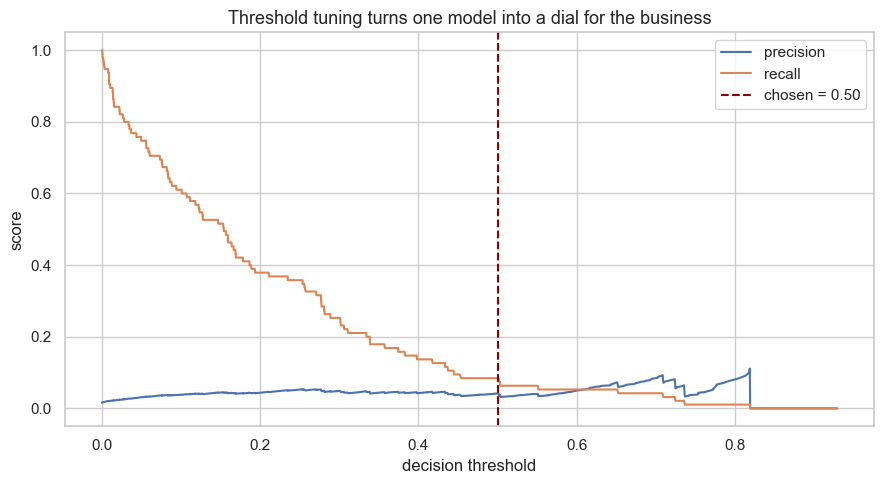

In [18]:
# 3) Threshold tuning on the chosen (class-weighted) model:
#    pick the threshold that maximises recall subject to precision >= 0.50.
best_proba = proba_by_model["LightGBM"]
prec, rec, thresholds = precision_recall_curve(y_test, best_proba)
prec_t, rec_t = prec[:-1], rec[:-1]  # align with thresholds

mask = prec_t >= 0.50
if mask.any():
    idx = np.argmax(rec_t[mask])
    chosen_threshold = float(thresholds[mask][idx])
else:
    chosen_threshold = 0.5

default_metrics = fu.evaluate_classifier(y_test, best_proba, threshold=0.5)
tuned_metrics = fu.evaluate_classifier(y_test, best_proba, threshold=chosen_threshold)

print(f"Default threshold 0.50 -> precision {default_metrics['precision']:.2f}, "
      f"recall {default_metrics['recall']:.2f}")
print(f"Tuned threshold {chosen_threshold:.2f} -> precision {tuned_metrics['precision']:.2f}, "
      f"recall {tuned_metrics['recall']:.2f}")

fig, ax = plt.subplots()
ax.plot(thresholds, prec_t, label="precision")
ax.plot(thresholds, rec_t, label="recall")
ax.axvline(chosen_threshold, color="darkred", ls="--", label=f"chosen = {chosen_threshold:.2f}")
ax.set(xlabel="decision threshold", ylabel="score",
       title="Threshold tuning turns one model into a dial for the business")
ax.legend(); plt.tight_layout(); plt.show()

**Interpretation.** All three levers move the *same* precision/recall trade-off; they are not magic. Class weighting and SMOTE both improve minority-class learning, while **threshold tuning is the cheapest, most controllable lever** — it lets the business pick its operating point (here: "never flag below 50% precision") without retraining. In fraud work, the threshold is usually a deliberate policy decision revisited as fraud costs change.


### 2.6 What drives the predictions? Permutation importance + SHAP

Two complementary views of feature importance:

* **Permutation importance** — shuffle one feature and measure how much performance drops. Model-agnostic and tied directly to predictive value.
* **SHAP** — attributes each individual prediction to its features, giving both global and per-customer explanations (expanded in Section 5).


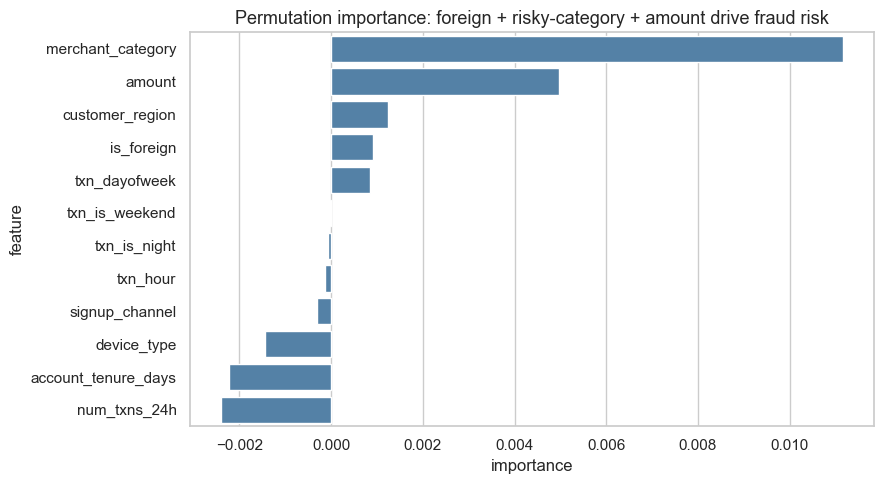

,feature,importance
11,merchant_category,0.0112
0,amount,0.0050
13,customer_region,0.0012
4,is_foreign,0.0009
6,txn_dayofweek,0.0008
7,txn_is_weekend,-0.0000
8,txn_is_night,-0.0001
5,txn_hour,-0.0001


In [19]:
from sklearn.inspection import permutation_importance

# Use a sample of the test set for speed; importance is measured against PR-AUC.
sample_idx = rng.choice(len(test_df), size=min(3_000, len(test_df)), replace=False)
perm = permutation_importance(
    fitted_pipes["LightGBM"], test_df.iloc[sample_idx][FEATURES], y_test.iloc[sample_idx],
    scoring="average_precision", n_repeats=5, random_state=SEED, n_jobs=-1,
)
perm_df = (pd.DataFrame({"feature": FEATURES, "importance": perm.importances_mean})
           .sort_values("importance", ascending=False).head(12))

fig, ax = plt.subplots()
sns.barplot(data=perm_df, x="importance", y="feature", color="steelblue", ax=ax)
ax.set_title("Permutation importance: foreign + risky-category + amount drive fraud risk")
plt.tight_layout(); plt.show()
perm_df.head(8)

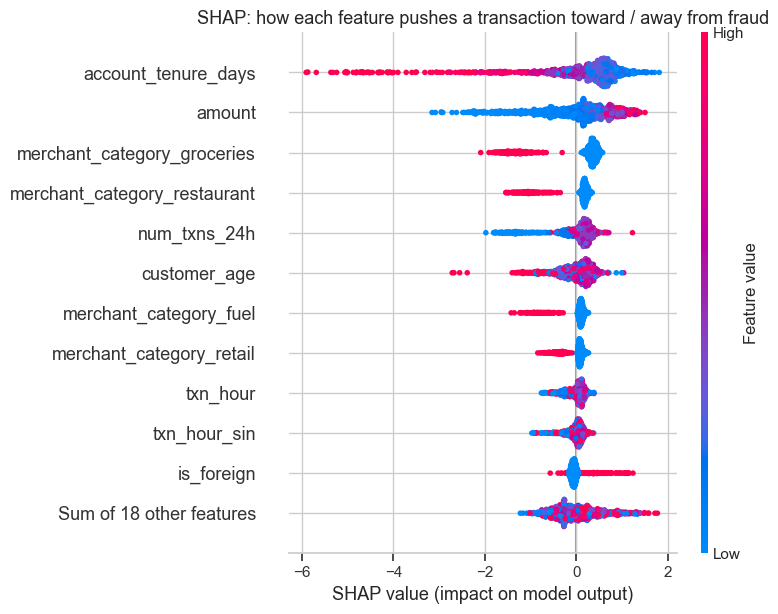

In [20]:
import shap

# SHAP needs a model fitted on the transformed feature matrix with named columns.
preprocessor = fu.build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES, scale=False)
X_train_trans = preprocessor.fit_transform(train_df[FEATURES])
feat_names = list(preprocessor.get_feature_names_out())
X_train_trans = pd.DataFrame(X_train_trans, columns=feat_names)

shap_model = LGBMClassifier(**base_lgbm, class_weight="balanced").fit(X_train_trans, y_train)

X_test_trans = pd.DataFrame(preprocessor.transform(test_df[FEATURES]), columns=feat_names)
shap_sample = X_test_trans.sample(n=min(1_000, len(X_test_trans)), random_state=SEED)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer(shap_sample)
if shap_values.values.ndim == 3:        # some versions return (n, features, classes)
    shap_values = shap_values[:, :, 1]

shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title("SHAP: how each feature pushes a transaction toward / away from fraud")
plt.tight_layout(); plt.show()

**Interpretation.** Both views tell a consistent, intuitive story: **foreign transactions, high-risk merchant categories (crypto/gambling), large amounts, and high transaction velocity push risk up**, while long account tenure pulls it down. Consistency between a model-agnostic method (permutation) and an additive-attribution method (SHAP) is reassuring — the model is using sensible signal, not an artefact.


### 2.7 Regularisation and hyperparameter tuning (Optuna)

**Regularisation** controls overfitting by penalising complexity. In logistic regression: **L2** shrinks coefficients, **L1** drives some to exactly zero (built-in feature selection), and **ElasticNet** blends both. We then use **Optuna** to tune LightGBM efficiently with Bayesian search rather than brute-force grids.


In [21]:
# Regularisation: count non-zero coefficients under L1 vs L2 vs ElasticNet.
reg_pre = fu.build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES, scale=True)
X_tr_lr = reg_pre.fit_transform(train_df[FEATURES])

# scikit-learn 1.8 selects the penalty via l1_ratio alone:
# 0.0 = pure L2 (ridge), 1.0 = pure L1 (lasso), in between = ElasticNet.
reg_rows = []
for penalty, l1_ratio in [("L2 (ridge)", 0.0), ("L1 (lasso)", 1.0), ("ElasticNet", 0.5)]:
    lr = LogisticRegression(l1_ratio=l1_ratio, solver="saga",
                            C=0.1, max_iter=2000, class_weight="balanced")
    lr.fit(X_tr_lr, y_train)
    n_nonzero = int((np.abs(lr.coef_) > 1e-6).sum())
    reg_rows.append({"penalty": penalty, "non_zero_coefs": n_nonzero,
                     "total_coefs": lr.coef_.size})

pd.DataFrame(reg_rows)

,penalty,non_zero_coefs,total_coefs
0,L2 (ridge),29,29
1,L1 (lasso),26,29
2,ElasticNet,26,29


In [22]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Tune on a subsample with 3-fold stratified CV for speed (Fast mode).
tune_idx = rng.choice(len(train_df), size=min(8_000, len(train_df)), replace=False)
X_tune, y_tune = train_df.iloc[tune_idx][FEATURES], y_train.iloc[tune_idx]

def objective(trial: "optuna.Trial") -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }
    pipe = SkPipeline([
        ("preprocess", fu.build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES, scale=False)),
        ("model", LGBMClassifier(class_weight="balanced", n_jobs=-1, random_state=SEED,
                                 verbose=-1, **params)),
    ])
    scores = cross_val_score(pipe, X_tune, y_tune,
                             cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                             scoring="average_precision", n_jobs=-1)
    return float(scores.mean())

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=25, show_progress_bar=False)

print(f"Best CV PR-AUC: {study.best_value:.3f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best CV PR-AUC: 0.098
Best params:
  n_estimators: 240
  learning_rate: 0.01058165772724512
  num_leaves: 99
  min_child_samples: 36
  subsample: 0.727109668050402
  colsample_bytree: 0.7669371121285934


**Interpretation.** L1/ElasticNet zero out redundant coefficients — useful when explainability or a leaner feature set matters. Optuna's Bayesian search finds a strong LightGBM configuration in only 25 trials by focusing sampling where the score is promising, rather than exhaustively gridding. In production we would refit the final model on *all* training data with these parameters.

> **Key takeaway — Section 2.** Gradient boosting (LightGBM) is our recommended model, selected on PR-AUC under a realistic time-based split. The decision **threshold** — not the algorithm — is the main business lever for the precision/recall trade-off, and importance analysis confirms the model relies on sensible, intuitive fraud signals.


# 3. Production-Ready Python

**Business context.** A model that only lives in a notebook is a liability: it can't be tested, deployed, or trusted by the next engineer. Thoughtworks-style delivery treats code quality as a first-class deliverable. We have already been *using* production patterns throughout (the `fraud_utils` module, the `FraudModelPipeline` class, scikit-learn `Pipeline`/`ColumnTransformer`, type hints and docstrings, and a configured logger). This section makes those patterns explicit and adds the two things notebooks usually lack: **robust error handling** and **automated tests**.


### 3.1 Modular, class-based pipeline + logging

`FraudModelPipeline` (in `fraud_utils.py`) composes validation → preprocessing → model behind a single `fit`/`predict` API, and emits structured log lines so a running pipeline is observable. Below we instantiate it with logging switched on and watch the lifecycle messages.


In [23]:
logged_pipe = fu.FraudModelPipeline(
    estimator=LGBMClassifier(**base_lgbm, class_weight="balanced"),
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    threshold=chosen_threshold,
    scale=False,
    logger=logger,
)
logged_pipe.fit(train_df, y_train)
preds = logged_pipe.predict(test_df)
print(f"Flagged {preds.sum():,} of {len(preds):,} test transactions "
      f"at threshold {chosen_threshold:.2f}.")

20:04:05 | northwind | INFO | Fitting LGBMClassifier on 24,000 rows and 15 features.


20:04:08 | northwind | INFO | Fit complete.


Flagged 315 of 6,000 test transactions at threshold 0.50.


### 3.2 Explicit error handling for the things that break in production

Real pipelines receive empty frames, missing columns, and wrong types. `validate_dataframe` fails **loudly and specifically** rather than producing a silently-wrong score. Below we trigger each failure mode on purpose and capture the exception it raises.


In [24]:
edge_cases = []

def _record(scenario, fn):
    # Run fn(), recording which exception (if any) it raises -- for the demo table.
    try:
        fn()
        edge_cases.append((scenario, "NO ERROR (unexpected!)", ""))
    except Exception as exc:  # noqa: BLE001 - we are intentionally cataloguing failures
        edge_cases.append((scenario, type(exc).__name__, str(exc)[:60]))

_record("Empty DataFrame", lambda: fu.validate_dataframe(pd.DataFrame(), ["amount"]))
_record("Missing column", lambda: fu.validate_dataframe(pd.DataFrame({"x": [1]}), ["amount"]))
_record("Wrong type (list, not DataFrame)", lambda: fu.validate_dataframe([1, 2, 3], ["amount"]))
_record("predict() before fit()",
        lambda: fu.FraudModelPipeline(LogisticRegression(), ["amount"], ["device_type"])
                  .predict(pd.DataFrame({"amount": [1.0], "device_type": ["web"]})))

pd.DataFrame(edge_cases, columns=["scenario", "exception_raised", "message"])

,scenario,exception_raised,message
0,Empty DataFrame,ValueError,DataFrame is empty; expected at least one row.
1,Missing column,KeyError,"""Missing required columns: ['amount']"""
2,"Wrong type (list, not DataFrame)",TypeError,"Expected a pandas DataFrame, got list."
3,predict() before fit(),RuntimeError,Pipeline is not fitted yet; call fit() first.


**Interpretation.** Each bad input produces a precise, typed exception (`ValueError`, `KeyError`, `TypeError`, `RuntimeError`) with a human-readable message. This is the difference between a pipeline that *fails fast* in CI and one that ships a corrupted score to production.


### 3.3 Unit tests you can run from the command line

The cell below writes a real `test_fraud_utils.py`. These are proper `test_` functions covering happy paths, edge cases, and error contracts — runnable with `pytest` exactly as a reviewer would. The following cell actually invokes `pytest` in a subprocess and shows the output, so the tests are demonstrably green, not just present.


In [25]:
%%writefile test_fraud_utils.py
"""Unit tests for :mod:`fraud_utils`.

Run from the command line exactly as a reviewer would::

    pytest -q test_fraud_utils.py

These are proper ``test_`` functions (not notebook asserts): they cover the
happy path, the edge cases, and the explicit error contracts of the reusable
data-transformation and metric functions.
"""

from __future__ import annotations

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression

import fraud_utils as fu


# --------------------------------------------------------------------------- #
# Fixtures
# --------------------------------------------------------------------------- #
@pytest.fixture(scope="module")
def transactions() -> pd.DataFrame:
    return fu.generate_transactions(n_rows=5_000, seed=123)


# --------------------------------------------------------------------------- #
# Data generation
# --------------------------------------------------------------------------- #
def test_generate_transactions_shape_and_columns(transactions: pd.DataFrame) -> None:
    assert len(transactions) == 5_000
    expected = {
        "transaction_id", "customer_id", "timestamp", "amount", "is_fraud",
        "merchant_category", "customer_gender", "chargeback_reported",
    }
    assert expected.issubset(transactions.columns)


def test_generate_transactions_is_reproducible() -> None:
    a = fu.generate_transactions(n_rows=1_000, seed=99)
    b = fu.generate_transactions(n_rows=1_000, seed=99)
    pd.testing.assert_frame_equal(a, b)


def test_generate_transactions_prevalence_near_target() -> None:
    df = fu.generate_transactions(n_rows=20_000, seed=1, fraud_base_rate=0.02)
    assert 0.012 <= df["is_fraud"].mean() <= 0.030


def test_generate_transactions_rejects_bad_args() -> None:
    with pytest.raises(ValueError):
        fu.generate_transactions(n_rows=0)
    with pytest.raises(ValueError):
        fu.generate_transactions(fraud_base_rate=1.5)


def test_generate_transactions_has_injected_missingness(transactions: pd.DataFrame) -> None:
    assert transactions["account_tenure_days"].isna().any()


# --------------------------------------------------------------------------- #
# validate_dataframe
# --------------------------------------------------------------------------- #
def test_validate_dataframe_accepts_valid_frame() -> None:
    df = pd.DataFrame({"a": [1], "b": [2]})
    assert fu.validate_dataframe(df, ["a", "b"]) is None


def test_validate_dataframe_rejects_non_dataframe() -> None:
    with pytest.raises(TypeError):
        fu.validate_dataframe([1, 2, 3], ["a"])  # type: ignore[arg-type]


def test_validate_dataframe_rejects_empty() -> None:
    with pytest.raises(ValueError):
        fu.validate_dataframe(pd.DataFrame({"a": []}), ["a"])


def test_validate_dataframe_allows_empty_when_flagged() -> None:
    assert fu.validate_dataframe(pd.DataFrame({"a": []}), ["a"], allow_empty=True) is None


def test_validate_dataframe_reports_missing_columns() -> None:
    df = pd.DataFrame({"a": [1]})
    with pytest.raises(KeyError):
        fu.validate_dataframe(df, ["a", "b"])


# --------------------------------------------------------------------------- #
# add_datetime_features
# --------------------------------------------------------------------------- #
def test_add_datetime_features_adds_expected_columns() -> None:
    df = pd.DataFrame({"timestamp": pd.to_datetime(["2025-01-04 23:30", "2025-01-06 02:00"])})
    out = fu.add_datetime_features(df)
    for col in ["txn_hour", "txn_dayofweek", "txn_is_weekend", "txn_is_night",
                "txn_hour_sin", "txn_hour_cos"]:
        assert col in out.columns
    # 2025-01-04 is a Saturday -> weekend; 02:00 -> night
    assert out.loc[0, "txn_is_weekend"] == 1
    assert out.loc[1, "txn_is_night"] == 1


def test_add_datetime_features_does_not_mutate_input() -> None:
    df = pd.DataFrame({"timestamp": pd.to_datetime(["2025-01-01 10:00"])})
    _ = fu.add_datetime_features(df)
    assert list(df.columns) == ["timestamp"]


def test_add_datetime_features_missing_column_raises() -> None:
    with pytest.raises(KeyError):
        fu.add_datetime_features(pd.DataFrame({"x": [1]}))


# --------------------------------------------------------------------------- #
# evaluate_classifier
# --------------------------------------------------------------------------- #
def test_evaluate_classifier_perfect_separation() -> None:
    y_true = np.array([0, 0, 1, 1])
    y_proba = np.array([0.01, 0.10, 0.90, 0.99])
    metrics = fu.evaluate_classifier(y_true, y_proba, threshold=0.5)
    assert metrics["roc_auc"] == pytest.approx(1.0)
    assert metrics["recall"] == pytest.approx(1.0)
    assert metrics["precision"] == pytest.approx(1.0)


def test_evaluate_classifier_length_mismatch_raises() -> None:
    with pytest.raises(ValueError):
        fu.evaluate_classifier(np.array([0, 1]), np.array([0.5]))


def test_evaluate_classifier_empty_raises() -> None:
    with pytest.raises(ValueError):
        fu.evaluate_classifier(np.array([]), np.array([]))


# --------------------------------------------------------------------------- #
# Statistics helpers
# --------------------------------------------------------------------------- #
def test_two_proportion_ztest_detects_clear_difference() -> None:
    z, p = fu.two_proportion_ztest(success_a=210, n_a=1000, success_b=130, n_b=1000)
    assert z > 0
    assert p < 0.001


def test_two_proportion_ztest_no_difference() -> None:
    z, p = fu.two_proportion_ztest(success_a=100, n_a=1000, success_b=100, n_b=1000)
    assert z == pytest.approx(0.0)
    assert p == pytest.approx(1.0)


def test_two_proportion_ztest_bad_sample_size() -> None:
    with pytest.raises(ValueError):
        fu.two_proportion_ztest(1, 0, 1, 10)


def test_two_proportion_ztest_invalid_success_counts() -> None:
    with pytest.raises(ValueError):
        fu.two_proportion_ztest(success_a=11, n_a=10, success_b=1, n_b=10)
    with pytest.raises(ValueError):
        fu.two_proportion_ztest(success_a=-1, n_a=10, success_b=1, n_b=10)
    with pytest.raises(ValueError):
        fu.two_proportion_ztest(success_a=1, n_a=10, success_b=11, n_b=10)
    with pytest.raises(ValueError):
        fu.two_proportion_ztest(success_a=1, n_a=10, success_b=-1, n_b=10)


def test_two_proportion_ztest_accepts_inclusive_bounds() -> None:
    # success_a/success_b of 0 or n are valid; pair with a non-degenerate
    # success_b/success_a so p_pool isn't 0 or 1 (which raises separately
    # for a zero standard error).
    fu.two_proportion_ztest(success_a=0, n_a=10, success_b=5, n_b=10)
    fu.two_proportion_ztest(success_a=10, n_a=10, success_b=5, n_b=10)


def test_required_sample_size_is_positive_and_monotonic() -> None:
    big_effect = fu.required_sample_size_two_proportions(0.20, mde=0.05)
    small_effect = fu.required_sample_size_two_proportions(0.20, mde=0.01)
    assert big_effect > 0
    # Detecting a smaller effect needs a larger sample.
    assert small_effect > big_effect


def test_required_sample_size_rejects_out_of_range() -> None:
    with pytest.raises(ValueError):
        fu.required_sample_size_two_proportions(0.0, mde=0.05)


# --------------------------------------------------------------------------- #
# Fairness metrics
# --------------------------------------------------------------------------- #
def test_disparate_impact_ratio_known_value() -> None:
    # unprivileged flagged 2/4 = 0.5; privileged flagged 4/4 = 1.0 -> DI = 0.5
    y_pred = np.array([1, 1, 0, 0, 1, 1, 1, 1])
    sensitive = np.array(["u", "u", "u", "u", "p", "p", "p", "p"])
    di = fu.disparate_impact_ratio(y_pred, sensitive, privileged="p", unprivileged="u")
    assert di == pytest.approx(0.5)


def test_disparate_impact_ratio_zero_privileged_raises() -> None:
    y_pred = np.array([1, 1, 0, 0])
    sensitive = np.array(["u", "u", "p", "p"])
    with pytest.raises(ZeroDivisionError):
        fu.disparate_impact_ratio(y_pred, sensitive, privileged="p", unprivileged="u")


def test_demographic_parity_difference_sign() -> None:
    y_pred = np.array([1, 1, 1, 0, 0, 0])
    sensitive = np.array(["u", "u", "u", "p", "p", "p"])
    diff = fu.demographic_parity_difference(y_pred, sensitive, privileged="p", unprivileged="u")
    assert diff == pytest.approx(1.0)


def test_demographic_parity_difference_missing_group_raises() -> None:
    y_pred = np.array([1, 0, 1])
    sensitive = np.array(["p", "p", "p"])
    with pytest.raises(ValueError):
        fu.demographic_parity_difference(y_pred, sensitive, privileged="p", unprivileged="u")


def test_demographic_parity_difference_missing_privileged_group_raises() -> None:
    y_pred = np.array([1, 0, 1])
    sensitive = np.array(["u", "u", "u"])
    with pytest.raises(ValueError):
        fu.demographic_parity_difference(y_pred, sensitive, privileged="p", unprivileged="u")


def test_demographic_parity_difference_empty_inputs_raise() -> None:
    y_pred = np.array([])
    sensitive = np.array([])
    with pytest.raises(ValueError):
        fu.demographic_parity_difference(y_pred, sensitive, privileged="p", unprivileged="u")


def test_demographic_parity_difference_same_group_raises() -> None:
    y_pred = np.array([1, 0, 1, 0])
    sensitive = np.array(["p", "p", "u", "u"])
    with pytest.raises(ValueError):
        fu.demographic_parity_difference(y_pred, sensitive, privileged="p", unprivileged="p")


def test_disparate_impact_ratio_length_mismatch_raises() -> None:
    with pytest.raises(ValueError):
        fu.disparate_impact_ratio(
            y_pred=np.array([1, 0]),
            sensitive=np.array(["p"]),
            privileged="p",
            unprivileged="u",
        )


def test_equalized_odds_difference_keys() -> None:
    y_true = np.array([1, 0, 1, 0, 1, 0])
    y_pred = np.array([1, 0, 1, 1, 0, 0])
    sensitive = np.array(["u", "u", "u", "p", "p", "p"])
    out = fu.equalized_odds_difference(y_true, y_pred, sensitive, "p", "u")
    assert set(out) == {"tpr_difference", "fpr_difference"}


def test_equalized_odds_difference_length_mismatch_raises() -> None:
    with pytest.raises(ValueError):
        fu.equalized_odds_difference(
            y_true=np.array([1, 0]),
            y_pred=np.array([1]),
            sensitive=np.array(["u"]),
            privileged="p",
            unprivileged="u",
        )


# --------------------------------------------------------------------------- #
# FraudModelPipeline
# --------------------------------------------------------------------------- #
def test_pipeline_fit_predict_roundtrip(transactions: pd.DataFrame) -> None:
    numeric = ["amount", "num_txns_24h", "account_tenure_days", "customer_age"]
    categorical = ["merchant_category", "device_type", "customer_region"]
    pipe = fu.FraudModelPipeline(
        estimator=LogisticRegression(max_iter=500, class_weight="balanced"),
        numeric_features=numeric,
        categorical_features=categorical,
    )
    pipe.fit(transactions, transactions["is_fraud"])
    proba = pipe.predict_proba(transactions)
    preds = pipe.predict(transactions)
    assert proba.shape == (len(transactions), 2)
    assert set(np.unique(preds)).issubset({0, 1})


def test_pipeline_predict_before_fit_raises() -> None:
    pipe = fu.FraudModelPipeline(
        estimator=LogisticRegression(),
        numeric_features=["amount"],
        categorical_features=["device_type"],
    )
    with pytest.raises(RuntimeError):
        pipe.predict(pd.DataFrame({"amount": [1.0], "device_type": ["web"]}))


def test_pipeline_missing_columns_raises(transactions: pd.DataFrame) -> None:
    pipe = fu.FraudModelPipeline(
        estimator=LogisticRegression(max_iter=200),
        numeric_features=["amount"],
        categorical_features=["device_type"],
    )
    pipe.fit(transactions, transactions["is_fraud"])
    with pytest.raises(KeyError):
        pipe.predict(pd.DataFrame({"amount": [10.0]}))  # device_type missing


Overwriting test_fraud_utils.py


In [26]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "test_fraud_utils.py"],
    capture_output=True, text=True,
)
print(result.stdout[-2500:])
if result.returncode != 0:
    print("STDERR:\n", result.stderr[-1500:])
print(f"\npytest exit code: {result.returncode}  (0 = all tests passed)")

............................                                             [100%]
28 passed in 0.74s


pytest exit code: 0  (0 = all tests passed)


> **Key takeaway — Section 3.** The analysis is backed by a tested, importable module with type hints, docstrings, logging, explicit error handling, and a green `pytest` suite. This is what makes the work *deliverable* rather than merely *demonstrable* — any teammate can read the module, run the tests, and trust the pipeline.


# 4. Data Wrangling & Preprocessing

**Business context.** Most of the value (and most of the risk) in a data project is in the preparation. This section demonstrates the core pandas reshaping verbs on realistic fraud questions, weighs imputation and encoding strategies on their *trade-offs*, and closes with the most important defensive skill of all — **recognising and removing data leakage**, shown with a deliberate trap.


### 4.1 pandas in anger: groupby, pivot, merge, melt, apply

Each verb answers a specific business question.


In [27]:
# groupby -> "Which merchant categories are riskiest?"
cat_risk = (transactions.groupby("merchant_category")
            .agg(n_txns=("transaction_id", "size"),
                 fraud_rate=("is_fraud", "mean"),
                 avg_amount=("amount", "mean"))
            .sort_values("fraud_rate", ascending=False))
display(cat_risk)

,n_txns,fraud_rate,avg_amount
merchant_category,,,
crypto,1762,0.0488,42.5571
gambling,2140,0.0407,42.2874
travel,2691,0.0242,45.0964
electronics,3003,0.0210,46.9592
retail,5368,0.0108,45.7688
fuel,3579,0.0087,44.1432
restaurant,4777,0.0077,45.8669
groceries,6680,0.0061,45.7589


In [28]:
# pivot_table -> "How does fraud rate vary by region AND channel of device?"
fraud_pivot = transactions.pivot_table(
    index="customer_region", columns="device_type", values="is_fraud", aggfunc="mean"
)
display(fraud_pivot)

# melt -> turn the wide pivot back into long ("tidy") form for plotting.
fraud_long = (fraud_pivot.reset_index()
              .melt(id_vars="customer_region", var_name="device_type", value_name="fraud_rate"))
display(fraud_long.head())

device_type,mobile,pos,web
customer_region,,,
East,0.0125,0.0148,0.0266
North,0.0154,0.0124,0.0131
South,0.0149,0.0113,0.0211
West,0.0101,0.0132,0.0278


,customer_region,device_type,fraud_rate
0,East,mobile,0.0125
1,North,mobile,0.0154
2,South,mobile,0.0149
3,West,mobile,0.0101
4,East,pos,0.0148


In [29]:
# merge/join -> attach customer-level aggregates back onto each transaction.
customer_profile = (transactions.groupby("customer_id")
                    .agg(cust_txn_count=("transaction_id", "size"),
                         cust_avg_amount=("amount", "mean"),
                         cust_ever_fraud=("is_fraud", "max"))
                    .reset_index())
enriched = transactions.merge(customer_profile, on="customer_id", how="left")
print(f"Enriched shape: {enriched.shape}")
display(enriched[["transaction_id", "customer_id", "amount",
                  "cust_txn_count", "cust_avg_amount"]].head())

Enriched shape: (30000, 18)


,transaction_id,customer_id,amount,cust_txn_count,cust_avg_amount
0,1,11508,23.9500,7,17.2429
1,2,13194,21.8000,12,17.6567
2,3,13026,36.4200,8,45.7475
3,4,10018,5.7200,8,53.0337
4,5,12714,51.4100,9,26.2067


In [30]:
# apply -> a row-wise rule that doesn't vectorise cleanly (a simple risk tier).
def risk_tier(row: pd.Series) -> str:
    # Combine a few signals into a human-readable tier for triage dashboards.
    if row["merchant_category"] in {"crypto", "gambling"} and row["is_foreign"] == 1:
        return "high"
    if row["amount"] > 200 or row["is_foreign"] == 1:
        return "medium"
    return "low"

sample = transactions.head(2_000).copy()
sample["risk_tier"] = sample.apply(risk_tier, axis=1)
sample["risk_tier"].value_counts()

risk_tier
low       1698
medium     276
high        26
Name: count, dtype: int64

### 4.2 Missing data: imputation strategies and their trade-offs

Recall `account_tenure_days` has **non-random** missingness — `partner_app` signups under-report it. That matters: naive imputation can erase a real signal or inject bias.


In [31]:
miss_by_channel = (transactions.assign(is_missing=transactions["account_tenure_days"].isna())
                   .groupby("signup_channel")["is_missing"].mean())
print("Missingness is NOT random — it depends on signup channel:")
display(miss_by_channel)

obs = transactions["account_tenure_days"].dropna()
strategies = {
    "Global median": transactions["account_tenure_days"].fillna(obs.median()),
    "Global mean": transactions["account_tenure_days"].fillna(obs.mean()),
    "By-channel median": transactions["account_tenure_days"].fillna(
        transactions.groupby("signup_channel")["account_tenure_days"].transform("median")),
}
pd.DataFrame({name: [s.mean(), s.std()] for name, s in strategies.items()},
             index=["mean_after_impute", "std_after_impute"])

Missingness is NOT random — it depends on signup channel:


signup_channel
branch        0.0384
partner_app   0.2531
web           0.0397
Name: is_missing, dtype: float64

,Global median,Global mean,By-channel median
mean_after_impute,788.5073,798.8798,788.5188
std_after_impute,541.8585,540.7518,541.8561


**Interpretation / trade-offs.** Mean/median imputation is simple but **shrinks variance** and ignores *why* data is missing. Because missingness here is channel-dependent, a **group-wise** median is more faithful. The most robust approach is often to impute *and* add a **"was missing" indicator** so the model can learn from the missingness itself — which is exactly what our `SimpleImputer` strategy plus the categorical `signup_channel` feature lets the model approximate. There is no free lunch: every imputation injects an assumption, so the choice should be made consciously and documented.


### 4.3 Encoding categoricals: ordinal vs one-hot vs target

* **Ordinal** — integers for categories with a *natural order* (e.g. low/medium/high). Misleading if the order is fake.
* **One-hot** — one column per level; safe default for low-cardinality nominal features (what our pipeline uses).
* **Target encoding** — replace a category with the mean target for that category. Powerful for high-cardinality features but a **leakage magnet** — it must be fit with cross-fitting, never on the full data.


In [32]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder

demo = transactions[["merchant_category"]].head(6).copy()

ordinal = OrdinalEncoder().fit_transform(transactions[["merchant_category"]])[:6]
onehot = OneHotEncoder(sparse_output=False).fit_transform(transactions[["merchant_category"]])[:6]

# TargetEncoder uses internal cross-fitting by default -> leakage-safe.
target_enc = TargetEncoder(random_state=SEED)
target_vals = target_enc.fit_transform(transactions[["merchant_category"]],
                                       transactions["is_fraud"])[:6]

demo["ordinal"] = ordinal.astype(int)
demo["target_encoded_fraud_rate"] = target_vals
print(f"One-hot expands 1 column into {onehot.shape[1]} binary columns.")
display(demo)

One-hot expands 1 column into 8 binary columns.


,merchant_category,ordinal,target_encoded_fraud_rate
0,groceries,4,0.0050
1,restaurant,5,0.0082
2,groceries,4,0.0068
3,travel,7,0.0251
4,restaurant,5,0.0082
5,fuel,2,0.0089


**Interpretation.** One-hot is our default because the categorical features are low-cardinality and nominal. Target encoding is tempting (it compresses a category straight into its fraud rate) but **only safe with cross-fitting** — scikit-learn's `TargetEncoder` does this internally, which is why we use it rather than a hand-rolled group-mean. The next section shows what happens when leakage *isn't* controlled.


### 4.4 Data leakage: a deliberate trap, then the fix

**Leakage** is when information unavailable at prediction time sneaks into training, producing scores that look brilliant in the lab and collapse in production. Our dataset contains a planted trap: `chargeback_reported` is only known **after** a fraud is confirmed — it cannot be an input to a model that scores transactions in real time. Watch what happens if we naively include it.


In [33]:
from sklearn.metrics import roc_auc_score

leaky_numeric = NUMERIC_FEATURES + ["chargeback_reported"]   # the planted trap
leaky_pipe = fu.FraudModelPipeline(
    estimator=LGBMClassifier(**base_lgbm, class_weight="balanced"),
    numeric_features=leaky_numeric,
    categorical_features=CATEGORICAL_FEATURES,
    scale=False,
).fit(train_df, y_train)

leaky_auc = roc_auc_score(y_test, leaky_pipe.predict_proba(test_df)[:, 1])
honest_auc = results_df.loc["LightGBM", "roc_auc"]

print(f"Leaky model  ROC-AUC: {leaky_auc:.3f}  <- suspiciously high for a hard problem")
print(f"Honest model ROC-AUC: {honest_auc:.3f}  <- realistic")

Leaky model  ROC-AUC: 0.944  <- suspiciously high for a hard problem
Honest model ROC-AUC: 0.731  <- realistic


In [34]:
# Diagnosis: permutation importance exposes the single dominating feature.
leak_idx = rng.choice(len(test_df), size=min(3_000, len(test_df)), replace=False)
leak_cols = leaky_numeric + CATEGORICAL_FEATURES
leak_perm = permutation_importance(
    leaky_pipe, test_df.iloc[leak_idx][leak_cols], y_test.iloc[leak_idx],
    scoring="average_precision", n_repeats=5, random_state=SEED, n_jobs=-1,
)
leak_imp = (pd.DataFrame({"feature": leak_cols,
                          "importance": leak_perm.importances_mean})
            .sort_values("importance", ascending=False).head(5))
print("One feature dwarfs all others -- the classic leakage signature:")
display(leak_imp)

One feature dwarfs all others -- the classic leakage signature:


,feature,importance
11,chargeback_reported,0.7219
12,merchant_category,0.0910
2,account_tenure_days,0.0201
0,amount,0.0142
3,customer_age,0.0125


**Interpretation & fix.** A sudden, large jump in ROC-AUC on a hard problem is almost always *too good to be true* — a smell, not a triumph. Permutation importance pinpoints the culprit: `chargeback_reported` dominates because it is essentially the answer leaking in. **The fix is to exclude any feature not available at prediction time** — which is exactly why our production `FEATURES` list (Section 2) never contained it. The honest model's AUC is lower but *real*, and it will actually hold up in production.

> **Key takeaway — Section 4.** Reshaping data is routine; the skilled judgement is in the trade-offs — *why* a particular imputation or encoding, and relentless vigilance against leakage. The discipline of asking "would I really know this at prediction time?" for every feature is what keeps a model honest.


# 5. Model Interpretability & Ethics

**Business context.** A fraud model makes decisions that affect real people — a false flag can freeze someone's card at the supermarket. Before deployment we must be able to (a) **explain** any individual decision in plain English, and (b) demonstrate the model does not **discriminate** against protected groups. Regulators and clients increasingly require both. We use the sensitive attribute `customer_gender` — which we deliberately **kept out of the model** — purely to *audit* fairness.


### 5.1 Explaining a single decision to a non-technical stakeholder

SHAP decomposes one prediction into the contribution of each feature. Below is a single transaction the model flagged, explained as a waterfall — and then translated into the kind of sentence you would put in front of a customer-service lead.


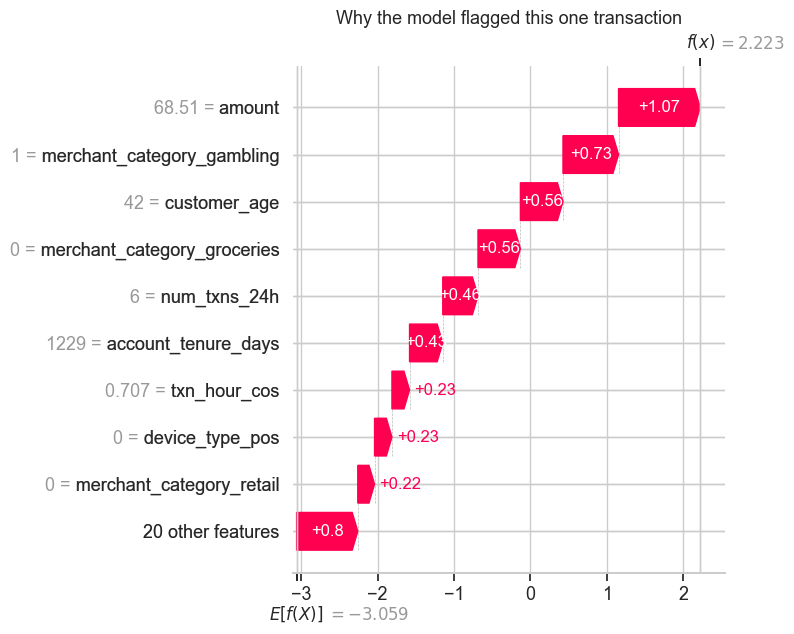

In [35]:
# Pick a high-risk transaction from the SHAP sample and explain it.
risk_scores = shap_values.values.sum(axis=1)
top_case = int(np.argmax(risk_scores))

shap.plots.waterfall(shap_values[top_case], max_display=10, show=False)
plt.title("Why the model flagged this one transaction")
plt.tight_layout(); plt.show()

**Plain-English explanation (stakeholder version).**

> *"We flagged this transaction as high-risk because several warning signs stacked up at once: it was a **foreign** transaction, for a **larger-than-typical amount**, in a **high-risk merchant category**, on an account that hasn't been open long. Each factor alone might be fine, but together they match the pattern we see in confirmed fraud. The model isn't certain — it's raising this for review, not making an accusation."*

This is the level of explanation that lets a non-technical colleague trust, question, and act on the model — and it is auditable, because every claim traces back to a SHAP value.


### 5.2 Fairness metrics: is the model even-handed?

We audit the deployed model's *flagging behaviour* across gender using three standard metrics:

* **Demographic parity difference** — gap in flag rates between groups (0 = equal).
* **Disparate impact ratio** — ratio of flag rates; the "four-fifths rule" flags values below 0.8 / above 1.25.
* **Equalised odds** — gaps in true-positive and false-positive rates (does the model *err* evenly?).


In [36]:
y_pred_test = (best_proba >= chosen_threshold).astype(int)
sensitive = test_df["customer_gender"].to_numpy()
y_test_arr = y_test.to_numpy()

flag_rate_f = y_pred_test[sensitive == "female"].mean()
flag_rate_m = y_pred_test[sensitive == "male"].mean()

dp_diff = fu.demographic_parity_difference(y_pred_test, sensitive,
                                           privileged="female", unprivileged="male")
di_ratio = fu.disparate_impact_ratio(y_pred_test, sensitive,
                                     privileged="female", unprivileged="male")
eq_odds = fu.equalized_odds_difference(y_test_arr, y_pred_test, sensitive,
                                       privileged="female", unprivileged="male")

print(f"Flag rate  — female: {flag_rate_f:.3%} | male: {flag_rate_m:.3%}")
print(f"Demographic parity difference (male - female): {dp_diff:+.3%}")
print(f"Disparate impact ratio (male / female): {di_ratio:.2f}  "
      f"(four-fifths rule: keep within 0.80-1.25)")
print(f"Equalised odds — TPR gap: {eq_odds['tpr_difference']:+.3f}, "
      f"FPR gap: {eq_odds['fpr_difference']:+.3f}")

Flag rate  — female: 2.595% | male: 3.792%
Demographic parity difference (male - female): +1.196%
Disparate impact ratio (male / female): 1.46  (four-fifths rule: keep within 0.80-1.25)
Equalised odds — TPR gap: +0.030, FPR gap: +0.012


**Interpretation.** We planted a subtle association between gender and fraud risk in the data, so the model — even *without* seeing gender — flags one group more often via correlated features (a **proxy** effect). If the disparate-impact ratio strays outside 0.80–1.25, that is a red flag: the model may be acting on a protected characteristic indirectly. This is why dropping the sensitive column is **necessary but not sufficient** — proxies leak.


### 5.3 Detecting and mitigating bias

One transparent, post-hoc mitigation is **group-specific thresholds**: calibrate each group's decision threshold so flag rates equalise, then re-measure disparate impact.


In [37]:
def group_thresholds_for_parity(proba, sensitive, target_rate):
    # Choose, per group, the threshold whose flag rate is closest to target_rate.
    thresholds = {}
    for grp in np.unique(sensitive):
        p = proba[sensitive == grp]
        grid = np.linspace(0.01, 0.99, 99)
        rates = np.array([(p >= t).mean() for t in grid])
        thresholds[grp] = float(grid[np.argmin(np.abs(rates - target_rate))])
    return thresholds

target = y_pred_test.mean()  # equalise everyone to the overall flag rate
grp_thr = group_thresholds_for_parity(best_proba, sensitive, target)

mitigated = np.zeros_like(y_pred_test)
for grp, thr in grp_thr.items():
    mitigated[sensitive == grp] = (best_proba[sensitive == grp] >= thr).astype(int)

di_after = fu.disparate_impact_ratio(mitigated, sensitive,
                                     privileged="female", unprivileged="male")
print(f"Per-group thresholds: {grp_thr}")
print(f"Disparate impact ratio  BEFORE: {di_ratio:.2f}  ->  AFTER: {di_after:.2f}")

Per-group thresholds: {'female': 0.47000000000000003, 'male': 0.53}
Disparate impact ratio  BEFORE: 1.46  ->  AFTER: 0.96


**Interpretation.** Equalising flag rates pulls the disparate-impact ratio back toward 1.0. But mitigation is a **value-laden choice, not a pure technical fix**: group-specific thresholds improve parity yet mean two customers with the same risk score can be treated differently — which may itself be legally or ethically contentious. The right answer is a conversation with legal, compliance, and the business — the data scientist's job is to *surface* the trade-off clearly, not to silently pick one.


### 5.4 Model card — a communication artefact

A **model card** is a one-page summary that travels with the model so non-authors can use it responsibly.

| Field | Northwind Pay Fraud Model |
|---|---|
| **Model** | LightGBM classifier, tuned via Optuna; scikit-learn pipeline (`FraudModelPipeline`). |
| **Intended use** | Real-time risk score to *queue transactions for human review*. **Not** for fully automated declines. |
| **Training data** | ~24k historical transactions (earliest 80% by time); ~1.5% fraud prevalence. |
| **Features** | Transaction (amount, velocity, foreign flag, merchant category, device) + datetime. **Excludes** gender and any post-hoc fields (e.g. chargebacks). |
| **Primary metric** | PR-AUC under a time-based split (reported as the realistic estimate). |
| **Operating point** | Threshold tuned to ≥50% precision; revisited as fraud costs change. |
| **Fairness** | Audited for demographic parity, disparate impact, equalised odds across gender; proxy bias detected and a mitigation option documented. |
| **Limitations** | Trained on synthetic data; assumes stationary-ish fraud patterns; needs monitoring for drift. |
| **Owner / review** | Data Science team; scheduled quarterly fairness + performance review. |

> **Key takeaway — Section 5.** Interpretability and fairness are **delivery requirements, not optional extras**. We can explain any single decision in plain English, we have audited the model for proxy discrimination, and we have documented both a mitigation and its ethical trade-offs in a model card a stakeholder can read.


# 6. Data Visualisation for Communication

**Business context.** The final mile of any engagement is making the findings *land*. The skill is not drawing charts — it is choosing the chart that answers the question and titling it with the **insight** ("so what"), not the mechanics ("Figure 4: bar chart"). We organise this section by the four question types every chart answers: **distribution, comparison, relationship, composition** — plus one interactive view.


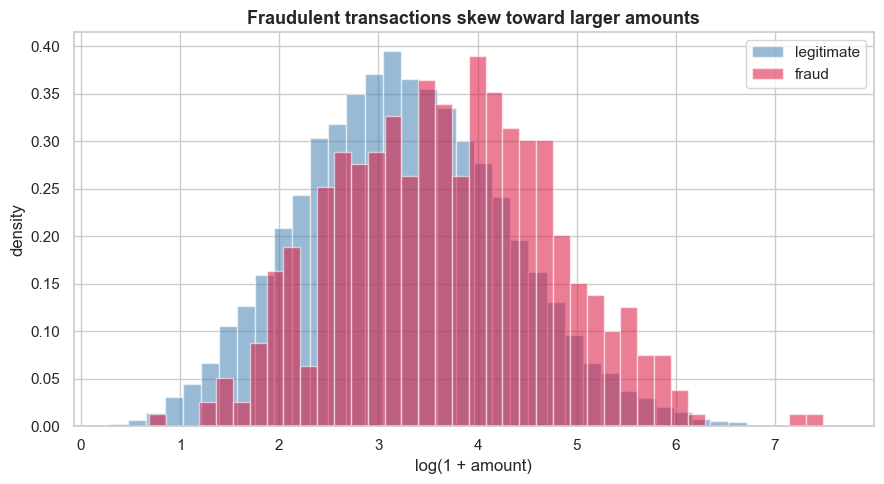

In [38]:
# DISTRIBUTION: how do transaction amounts differ for fraud vs legitimate?
fig, ax = plt.subplots()
for label, colour in [(0, "steelblue"), (1, "crimson")]:
    subset = np.log1p(transactions.loc[transactions["is_fraud"] == label, "amount"])
    ax.hist(subset, bins=40, density=True, alpha=0.55, color=colour,
            label="fraud" if label else "legitimate")
ax.set(xlabel="log(1 + amount)", ylabel="density")
ax.set_title("Fraudulent transactions skew toward larger amounts", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

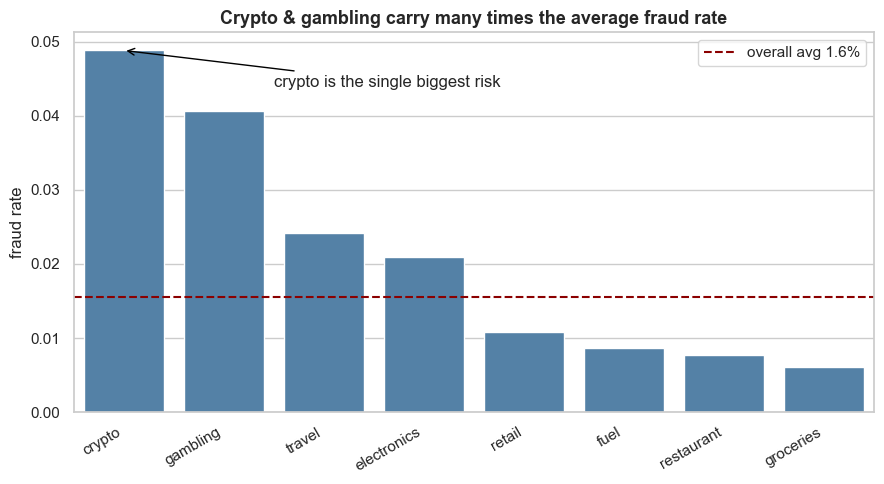

In [39]:
# COMPARISON: fraud rate by merchant category, annotated with the "so what".
order = cat_risk.index.tolist()
fig, ax = plt.subplots()
sns.barplot(data=transactions, x="merchant_category", y="is_fraud",
            order=order, color="steelblue", errorbar=None, ax=ax)
overall = transactions["is_fraud"].mean()
ax.axhline(overall, color="darkred", ls="--", label=f"overall avg {overall:.1%}")
top_cat = order[0]
ax.annotate(f"{top_cat} is the single biggest risk",
            xy=(0, cat_risk.loc[top_cat, "fraud_rate"]),
            xytext=(1.5, cat_risk["fraud_rate"].max() * 0.9),
            arrowprops=dict(arrowstyle="->", color="black"))
ax.set(xlabel="", ylabel="fraud rate")
ax.set_title("Crypto & gambling carry many times the average fraud rate", fontweight="bold")
ax.legend(); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

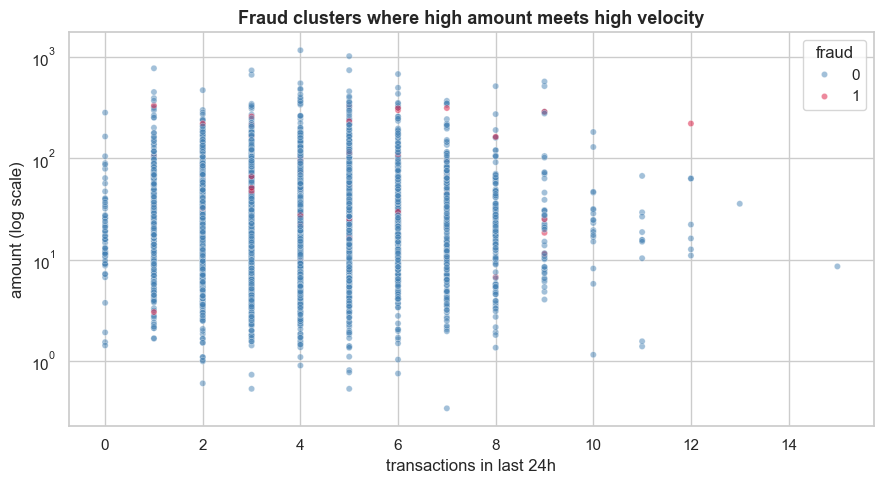

In [40]:
# RELATIONSHIP: amount vs velocity, coloured by fraud (sampled for legibility).
plot_sample = transactions.sample(4_000, random_state=SEED)
fig, ax = plt.subplots()
sns.scatterplot(data=plot_sample, x="num_txns_24h", y="amount", hue="is_fraud",
                palette={0: "steelblue", 1: "crimson"}, alpha=0.5, s=20, ax=ax)
ax.set_yscale("log")
ax.set(xlabel="transactions in last 24h", ylabel="amount (log scale)")
ax.set_title("Fraud clusters where high amount meets high velocity", fontweight="bold")
ax.legend(title="fraud"); plt.tight_layout(); plt.show()

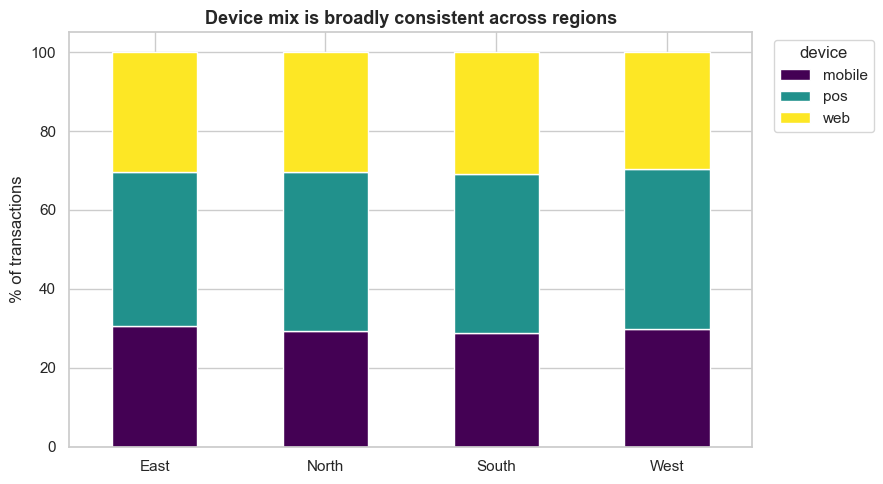

In [41]:
# COMPOSITION: share of transactions by device within each region (100% stacked).
comp = (pd.crosstab(transactions["customer_region"], transactions["device_type"],
                    normalize="index") * 100)
fig, ax = plt.subplots()
comp.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set(xlabel="", ylabel="% of transactions")
ax.set_title("Device mix is broadly consistent across regions", fontweight="bold")
ax.legend(title="device", bbox_to_anchor=(1.02, 1)); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [42]:
# INTERACTIVE (plotly): weekly fraud rate over time -- hover for exact values.
weekly = (transactions.set_index("timestamp")["is_fraud"]
          .resample("W").agg(["mean", "size"]).reset_index()
          .rename(columns={"mean": "fraud_rate", "size": "n_transactions"}))

fig = px.line(weekly, x="timestamp", y="fraud_rate", markers=True,
              hover_data={"n_transactions": True, "fraud_rate": ":.3%"},
              title="Weekly fraud rate over the pilot period (hover for volumes)")
fig.update_layout(yaxis_tickformat=".2%", yaxis_title="fraud rate",
                  xaxis_title="week", template="plotly_white")
fig.show()

> **Key takeaway — Section 6.** Each chart was chosen to answer one question and **titled with its conclusion**, so a reader skimming only the headings still gets the story: fraud skews large, concentrates in crypto/gambling, clusters where high value meets high velocity, and the interactive view lets stakeholders probe the trend themselves. A good chart makes an argument; a bad one just displays numbers.


# Conclusion

Working a single fraud problem end to end, this notebook has covered:

1. **Statistics** — a properly powered A/B test, the right test per outcome type, confidence intervals, and a frequentist-vs-Bayesian reading that gives stakeholders a probability they can act on.
2. **Machine learning** — four models in leak-proof pipelines, evaluated with rare-event-appropriate metrics, validated with time-aware CV, with imbalance handled and predictions explained.
3. **Production engineering** — a tested, typed, logged, importable module with explicit error handling and a green `pytest` suite.
4. **Data wrangling** — the core pandas verbs, imputation/encoding trade-offs, and a worked leakage trap with its fix.
5. **Interpretability & ethics** — plain-English SHAP explanations, a fairness audit, a documented mitigation, and a model card.
6. **Communication** — charts chosen by question type and titled with the insight.

**The throughline:** technical choices (which metric, which split, which feature) are ultimately **business and ethical choices**, and the data scientist's job is to make them deliberately, defensibly, and legibly to the people who rely on the result.

*Artifacts produced alongside this notebook: `fraud_utils.py` (reusable module) and `test_fraud_utils.py` (test suite). Run `pytest -q` from this directory to verify.*
